In [1]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster(n_workers=4, threads_per_worker=1,  memory_limit='6GB')
client = Client(cluster)

/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 35653 instead
  warnings.warn(


In [2]:
from tropical_cyclones import TCs, multi_plot, plot_trajectories
from aqua.core.util import load_yaml

config = load_yaml('/work/users/mccorda/tcs_stitch_csv/config_tcs_hr_stitch.yaml')  
                   #/home/mccorda/work/tc_analysis2/config_tcs_monthlystitch.yaml')

/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/intake_esm/__init__.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [3]:
# ===========================================
# 1. SETUP - Parametri da config
# ===========================================
import os
from glob import glob
from datetime import datetime

trackdir = config['paths']['trackdir']
tmpdir = config['paths']['tmpdir']

model = config['datasets'][0]['model']   # "IFS-FESOM"
exp = config['datasets'][0]['exp']       # "historical-1990"
data_dir = os.path.join(trackdir, model, exp)

start_date = datetime.strptime(config['time']['startdate'], "%Y%m%d")
end_date   = datetime.strptime(config['time']['enddate'], "%Y%m%d")

In [4]:
# ===========================================
# 2. SELEZIONE FILE - Trova i file tempest_track nel range di date
# ===========================================
all_files = sorted(glob(os.path.join(data_dir, "tempest_track_*.txt")))
filenames = []
for f in all_files:
    base = os.path.basename(f)
    try:
        parts = base.replace("tempest_track_", "").replace(".txt", "").split("-")
        start_f = datetime.strptime(parts[0], "%Y%m%d")
        end_f = datetime.strptime(parts[1], "%Y%m%d")
        if end_f >= start_date and start_f <= end_date:
            filenames.append(f)
    except:
        pass

print(f"[INFO] File selezionati: {len(filenames)}")

#Tenere a mente: se in futuro il config avrà più di un dataset in config['datasets'], 
# questo codice prende solo il primo ([0]). Per ora, con un solo dataset in lista ok così.

[INFO] File selezionati: 305


In [5]:
# ===========================================
# 3. MERGE FILE - CON STORM_ID UNICI
# ===========================================
os.makedirs(tmpdir, exist_ok=True)
tot_file = os.path.join(tmpdir, f"tempest_tracks_tot_{config['time']['startdate']}_{config['time']['enddate']}.txt")

global_storm_id = 0  # Contatore globale

with open(tot_file, 'w') as output_file:
    output_file.write("track_id year month day hour i j lon lat slp wind zs\n")
    
    for fname in filenames:
        with open(fname, 'r') as infile:
            lines = infile.readlines()
            
            if len(lines) == 0:
                print(f"[WARNING] File vuoto: {fname}")
                continue
            
            # Mappa storm_id locali -> storm_id globali
            local_to_global = {}
            
            for line in lines[1:]:  # Skippa header
                clean = line.replace(',', '').strip()
                if not clean:
                    continue
                parts = clean.split()
                if len(parts) != 12:
                    continue
                
                local_id = parts[0]
                
                # Assegna nuovo ID globale se è la prima volta che vediamo questo local_id
                if local_id not in local_to_global:
                    local_to_global[local_id] = str(global_storm_id)
                    global_storm_id += 1
                
                # Sostituisci con ID globale
                parts[0] = local_to_global[local_id]
                output_file.write(" ".join(parts) + "\n")

print(f"[INFO] File totale creato: {tot_file}")
print(f"[INFO] Totale storm unici: {global_storm_id}")

[INFO] File totale creato: /work/users/mccorda/tcs_stitch_csv/tmpdir/tempest_tracks_tot_19900101_20141231.txt
[INFO] Totale storm unici: 2552


In [7]:
#skippare il filtro (usare le tracce non filtrate) è ragionevole 
# perche ho già verificato quantitativamente, con ERA5, che il filtro cambia poco 
#con ERA5 la percentuale scartata era piccola (es. <5%), 
# skippare per IFS-FESOM è difendibile come approssimazione, 
# ma andrebbe comunque menzionato come limitazione nel metodo 
# (il filtro STJ serve a togliere sistemi extratropicali "falsi positivi" — 
# se lo salti, alcune tracce non-tropicali potrebbero restare dentro tc_data).
#se in futuro deciderai di ricostruire il filtro per IFS-FESOM, 
#ti basta reintrodurre la vera chiamata a filter_STJ_Bourdin250_monthly in questa cella, senza toccare nient'altro a valle.

In [6]:
# ===========================================
# 4. FILTRO STJ - SKIPPATO
# ===========================================
# Filtro STJ non applicato: con ERA5 la percentuale di tracce scartate
# era minima (<5%), quindi si procede direttamente con le tracce non filtrate.
filtered_file = tot_file

print(f"[INFO] Filtro STJ skippato. Uso tracce non filtrate: {filtered_file}")

[INFO] Filtro STJ skippato. Uso tracce non filtrate: /work/users/mccorda/tcs_stitch_csv/tmpdir/tempest_tracks_tot_19900101_20141231.txt


In [7]:
# ===========================================
# 5: load data (memory)
# ===========================================
import sys
import os

tools_path = '/home/mccorda/work/AQUA-diagnostics/frontier-diagnostics/tropical_cyclones/tropical_cyclones/tools/'
plots_path = '/home/mccorda/work/AQUA-diagnostics/frontier-diagnostics/tropical_cyclones/tropical_cyclones/plots/'

if tools_path not in sys.path:
    sys.path.insert(0, tools_path)
if plots_path not in sys.path:
    sys.path.insert(0, plots_path)

In [12]:
from tc_data_manager import TCDataManager
from plotting_TCs_custom_memory import *

# load data
tc_data = TCDataManager(filtered_file)
tc_data.summary()


LOADING TC DATA INTO MEMORY
Source: /work/users/mccorda/tcs_stitch_csv/tmpdir/tempest_tracks_tot_19900101_20141231.txt
  Parsed 63,864 observations from file
  Converting to numpy arrays...
  Building trajectory list...
✓ Data loaded successfully!
  Observations: 63,864
  Storms: 2552


TC DATA SUMMARY
Source file: /work/users/mccorda/tcs_stitch_csv/tmpdir/tempest_tracks_tot_19900101_20141231.txt
Total observations: 63,864
Total storms: 2552

Time period:
  Start: 1990-01
  End: 2014-12
  Duration: 300 months

Data ranges:
  SLP: 90319.0 - 102352.7 Pa
  Wind: 3.1 - 60.5 m/s
  Latitude: -75.5° to 74.5°
  Longitude: 0.0° to 359.0°

Memory usage:
  Total: 6.33 MB

Trajectory structure:
  Type: LIST (not dict)
  Length: 2552
  First storm ID: '0'
  Last storm ID: '2551'



In [9]:
tc_data.trajectories[54]

{'id': np.str_('54'),
 'lon': array([114., 115., 115., 115., 116., 116., 116., 116., 116., 116., 116.]),
 'lat': array([22.5, 22.5, 21.5, 21.5, 21.5, 21.5, 22.5, 22.5, 22.5, 22.5, 23.5]),
 'slp': array([99901.94, 99773.99, 99605.97, 99571.  , 99480.41, 99314.12,
        99266.02, 99315.21, 99350.48, 99468.22, 99445.1 ]),
 'wind': array([ 9.530152, 10.13668 , 11.44502 , 11.35228 , 12.22067 , 13.80286 ,
        12.19001 , 12.72673 , 13.22475 , 12.31198 , 10.53168 ]),
 'year': array([1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990]),
 'month': array([8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8]),
 'day': array([19, 20, 20, 20, 20, 21, 21, 21, 21, 22, 22]),
 'hour': array([18,  0,  6, 12, 18,  0,  6, 12, 18,  0,  6])}

Using data from memory (fast)
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_ICON_historical-1990_19900101_20141231.pdf


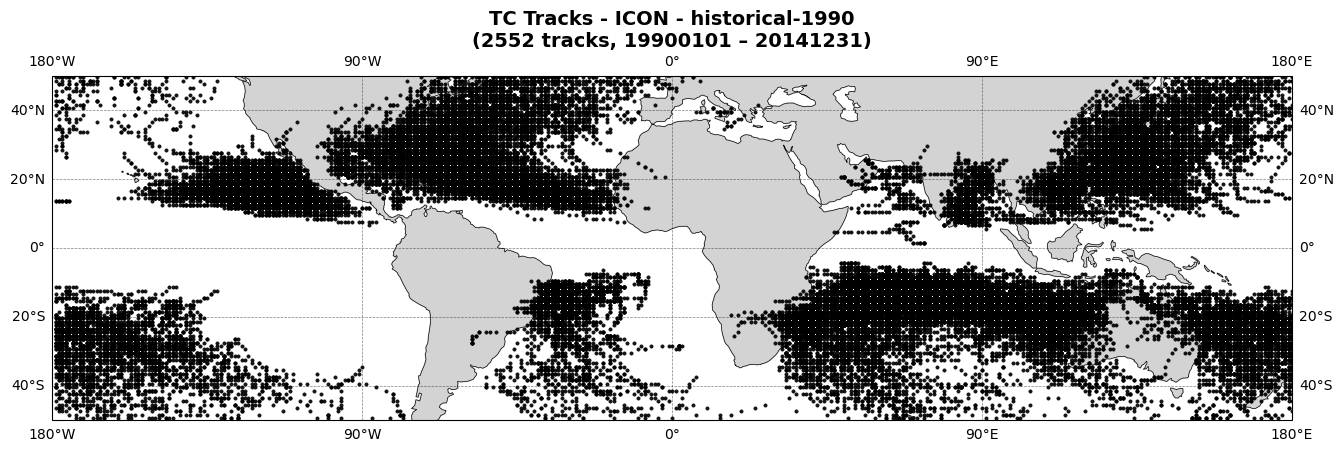

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_ICON_historical-1990_19900101_20141231.nc


In [13]:
# ===========================================
# 6: plots using tc_data in memory
# ===========================================

# plot_trajectories_direct si aspetta config['dataset'] (singolare),
# mentre il nostro config ha config['datasets'] (lista) 
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}

plot_trajectories_direct(tc_data, plot_config)

In [15]:
# ===========================================
# Boundaries fissi per la colorbar (0 - 1, condivisi tra tutti i dataset)
# ===========================================
import numpy as np

vmax_fixed = 1.0
vmin_fixed = 0.01
n_levels = 12

fixed_boundaries = np.logspace(np.log10(vmin_fixed), np.log10(vmax_fixed), n_levels + 1)
fixed_boundaries[0] = 0.0   # zero esatto -> bianco puro

print(fixed_boundaries)

[0.         0.01467799 0.02154435 0.03162278 0.04641589 0.06812921
 0.1        0.14677993 0.21544347 0.31622777 0.46415888 0.68129207
 1.        ]


Using data from memory (fast)
✓ Main dataset: 2,552 storms
✓ Category filter: all
✓ Storms contributing: 2,552
✓ Total storm-cap transits: 708,742
✓ Density denominator: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_catAll_ICON_historical-1990_19900101_20141231_allmonths.pdf


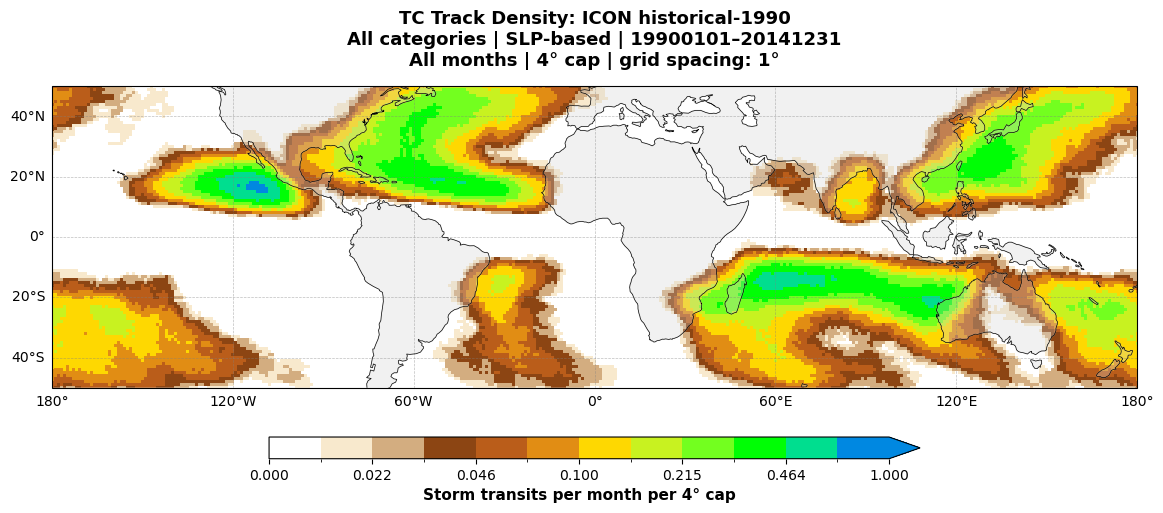

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_catAll_ICON_historical-1990_19900101_20141231_allmonths.nc
Using data from memory (fast)
✓ Main dataset: 717 storms
✓ Category filter: 3+ (slp)
✓ Storms contributing: 717
✓ Total storm-cap transits: 303,463
✓ Density denominator: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_cat3plus_ICON_historical-1990_19900101_20141231_allmonths.pdf


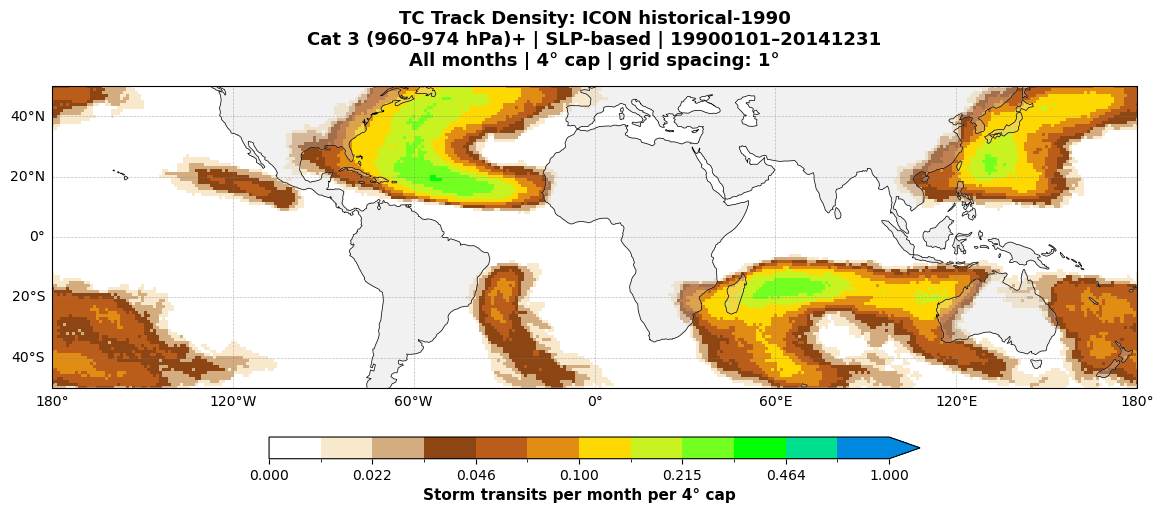

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_cat3plus_ICON_historical-1990_19900101_20141231_allmonths.nc
Using data from memory (fast)
✓ Main dataset: 1,835 storms
✓ Category filter: 2- (slp)
✓ Storms contributing: 1,835
✓ Total storm-cap transits: 405,279
✓ Density denominator: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_cat2minus_ICON_historical-1990_19900101_20141231_allmonths.pdf


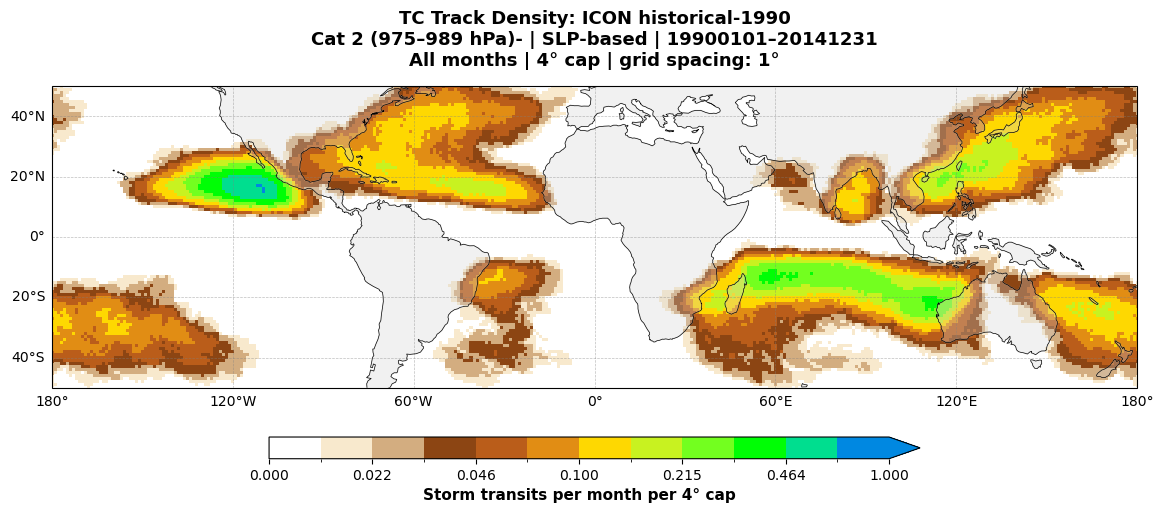

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_cat2minus_ICON_historical-1990_19900101_20141231_allmonths.nc


<xarray.Dataset> Size: 585kB
Dimensions:                            (latitude: 101, longitude: 360)
Coordinates:
  * longitude                          (longitude) int64 3kB -180 -179 ... 179
  * latitude                           (latitude) int64 808B -50 -49 ... 49 50
Data variables:
    storm_transits_per_month_4deg_cap  (latitude, longitude) float64 291kB 0....
    storm_transits_count               (latitude, longitude) float64 291kB 4....
Attributes: (12/16)
    model:                 ICON
    experiment:            historical-1990
    cat_method:            slp
    category_filter:       Cat 2 (975–989 hPa)
    category_direction:    minus
    density_definition:    storm transits per month per spherical cap
    ...                    ...
    enddate:               20141231
    n_months:              300
    difference:            False
    colour_boundaries:     [0.0, 0.014677992676220698, 0.021544346900318832, ...
    reference_model:       
    creation_date:         2026-09-14 23:30:24

In [16]:
plot_track_density_4deg_cap(
    tc_data, 
    plot_config,
    grid_size=1,
    cap_radius=4,
    fixed_boundaries=fixed_boundaries,
    cat_method='slp',
    season='all'
)

plot_track_density_4deg_cap(
    tc_data, 
    plot_config,
    grid_size=1,
    cap_radius=4,
    category="3+",
    fixed_boundaries=fixed_boundaries,
    cat_method='slp',
    season='all'
)

plot_track_density_4deg_cap(
    tc_data, 
    plot_config,
    grid_size=1,
    cap_radius=4,
    category="2-",
    fixed_boundaries=fixed_boundaries,
    cat_method='slp',
    season='all'
)

Reading from file (slow)...
Reading trajectories from file: /work/users/mccorda/tcs_stitch_csv/tmpdir/ICON/historical-1990/tempest_tracks_tot_19900101_20141231.txt
Found 2552 trajectories  |  sshs column: no (SLP fallback)
✓ Main dataset: 2,552 storms
✓ Category filter: all
✓ Storms contributing: 2,552
✓ Total storm-cap transits: 708,742
✓ Density denominator: 300 months
Reading from file (slow)...
Reading trajectories from file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19900101_20141231.txt
Found 1877 trajectories  |  sshs column: no (SLP fallback)
✓ Reference dataset: 1,877 storms
✓ Storms contributing: 1,877
✓ Total storm-cap transits: 481,358
✓ Density denominator: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_catAll_ICON_minus_ERA5_19900101_20141231_allmonths.pdf


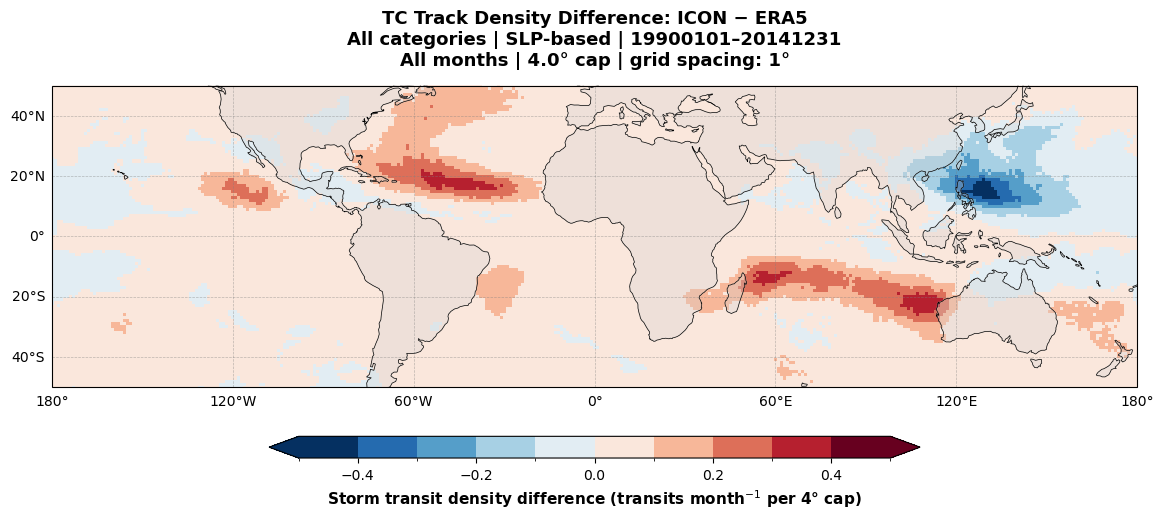

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_4degcap_slp_catAll_ICON_minus_ERA5_19900101_20141231_allmonths.nc


In [17]:
# ===========================================
# 12. DIFFERENZA ICON - ERA5, passando direttamente i path .txt
# ===========================================
import numpy as np

diff_vmax = 0.5   # scegli in base al range di differenze che ti aspetti
diff_boundaries = np.linspace(-diff_vmax, diff_vmax, 11)  # 10 livelli, zero esattamente al centro

# Parto dal config di ERA5 già presente in questo notebook, e ne clono
# due copie leggere solo per etichettare correttamente titolo/filename
config_ifs = dict(config)
config_ifs['dataset'] = {'model': 'ICON', 'exp': 'historical-1990'}

config_era5 = dict(config)
config_era5['dataset'] = {'model': 'ERA5', 'exp': 'era5'}

ds_diff = plot_track_density_4deg_cap(
    "/work/users/mccorda/tcs_stitch_csv/tmpdir/ICON/historical-1990/tempest_tracks_tot_19900101_20141231.txt",  # main: ICON
    config_ifs,
    cap_radius=4.0,
    grid_size=1,
    category=None,
    cat_method='slp',
    season='all',
    fixed_boundaries=diff_boundaries,
    reference_data_or_file="/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19900101_20141231.txt",  # reference: ERA5
    reference_tdict=config_era5,
    difference=True,   # ICON − ERA5
)

Using data from memory (fast)
Plotting all 2552 storms (cat_method=slp)
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_colored_slp_ICON_historical-1990_19900101_20141231.pdf


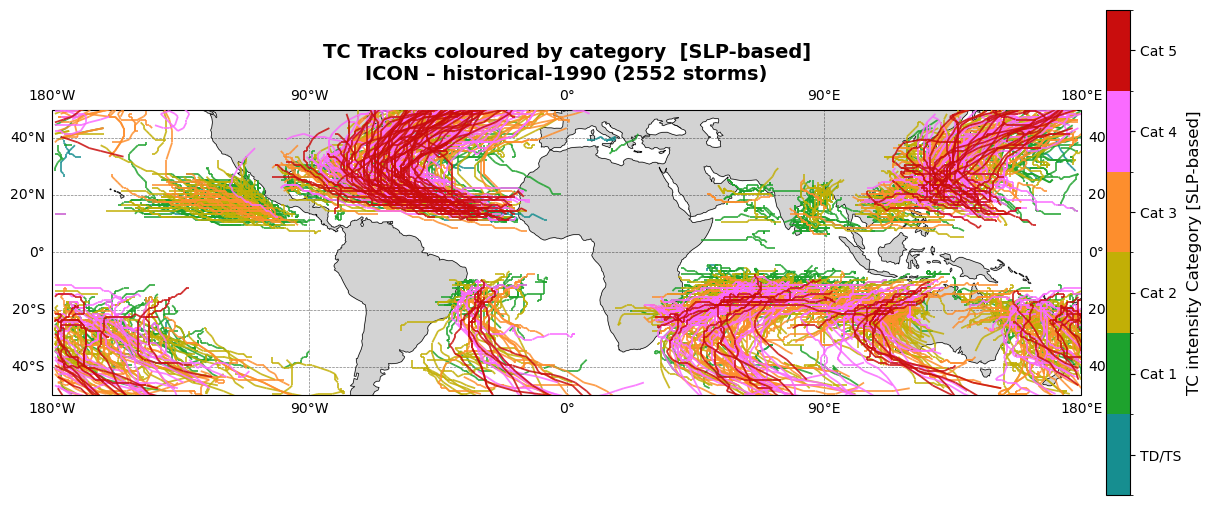

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_colored_slp_ICON_historical-1990_19900101_20141231.nc


In [11]:
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}

plot_trajectories_colored(tc_data, plot_config) 

Using data from memory (fast)
Plotting all 2484 storms colored by category
Plotting storms ordered: weak (background) → strong (foreground)
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_colored_category_ERA5_era5_19790101_20150106.pdf


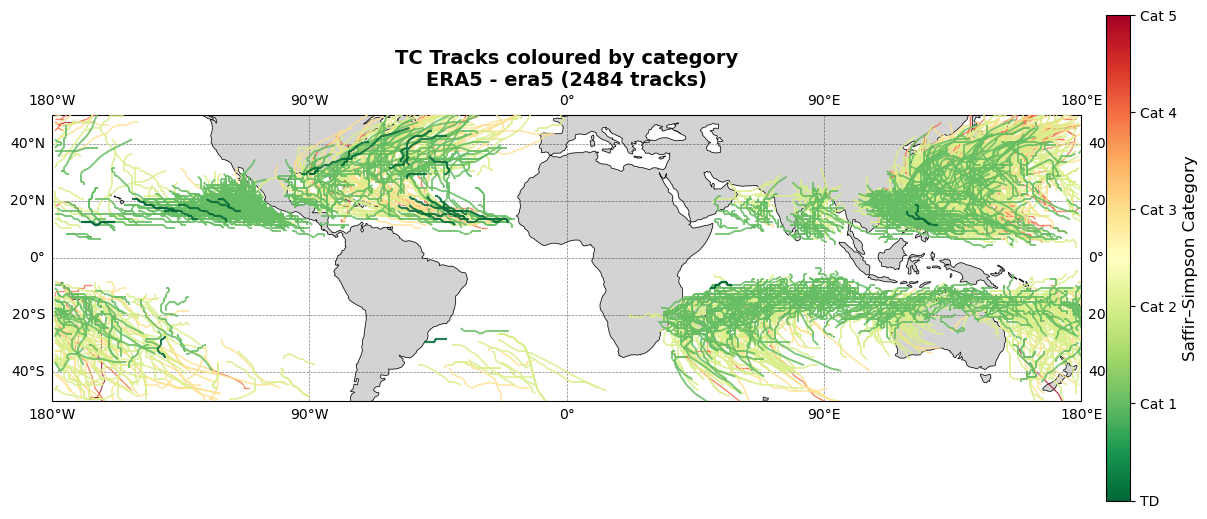

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_colored_category_ERA5_era5_19790101_20150106.nc


In [ ]:
# OPZIONE 1: Tutte le traiettorie colorate per categoria
#plot_trajectories_colored(tc_data, config, color_by='category')
plot_trajectories_colored(tc_data, config)  
# → Salva: tracks_colored_category_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
✓ Found 83 trajectories for Cat 4 (945–959 hPa)
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_cat4_slp_IFS-FESOM_historical-1990_19900101_20141231.pdf


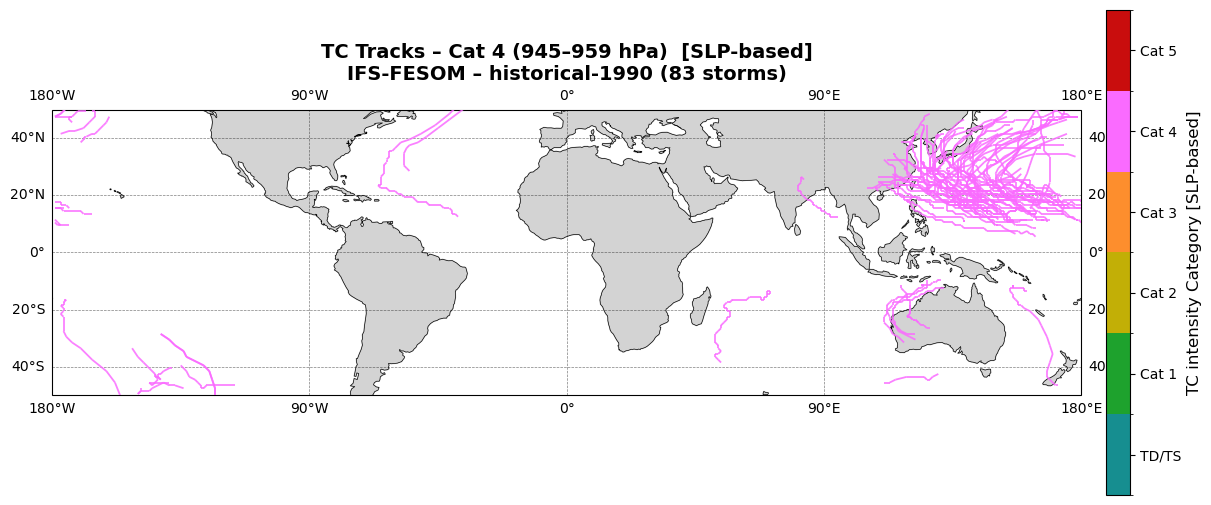

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/tracks_cat4_slp_IFS-FESOM_historical-1990_19900101_20141231.nc


In [13]:
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}
plot_trajectories_colored(tc_data, plot_config, category=4)

Using data from memory (fast)
Filtering for Cat 4 (945–959)...
✓ Found 100 trajectories for Cat 4 (945–959)


/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/work/users/mccorda/miniforge3/envs/aqua-diagnostics

✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat4_ERA5_era5_19790101_20150106.pdf


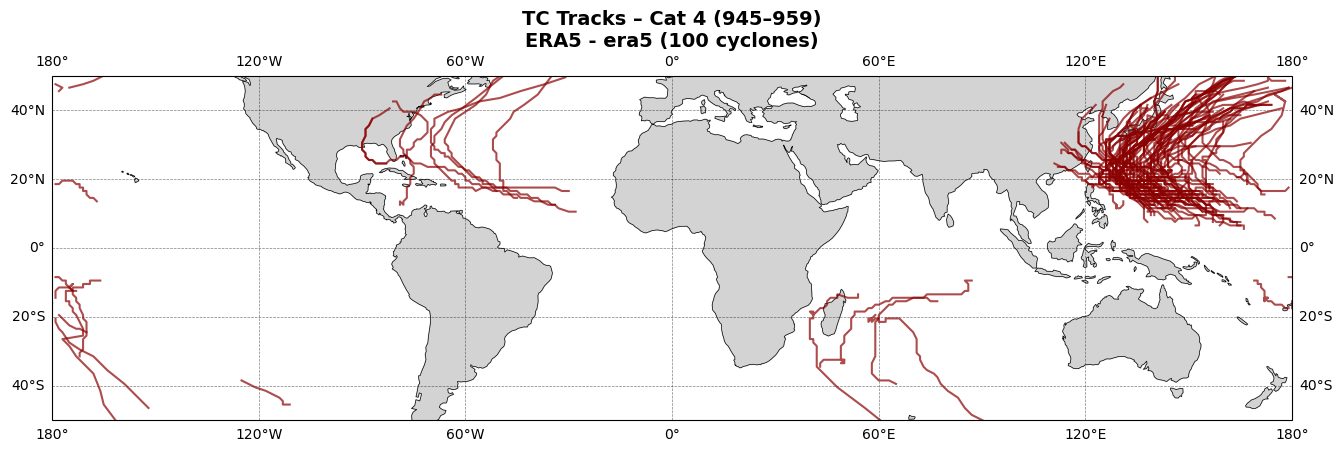

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat4_ERA5_era5_19790101_20150106.nc


In [ ]:
# OPZIONE 2: Solo Cat 4
plot_trajectories_colored(tc_data, config, category=4)
# → Salva: tracks_cat4_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
Filtering for Cat 5 (<945)...
✓ Found 7 trajectories for Cat 5 (<945)


/work/users/mccorda/miniforge3/envs/aqua-diagnostics/lib/python3.12/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)


✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat5_ERA5_era5_19790101_20150106.pdf


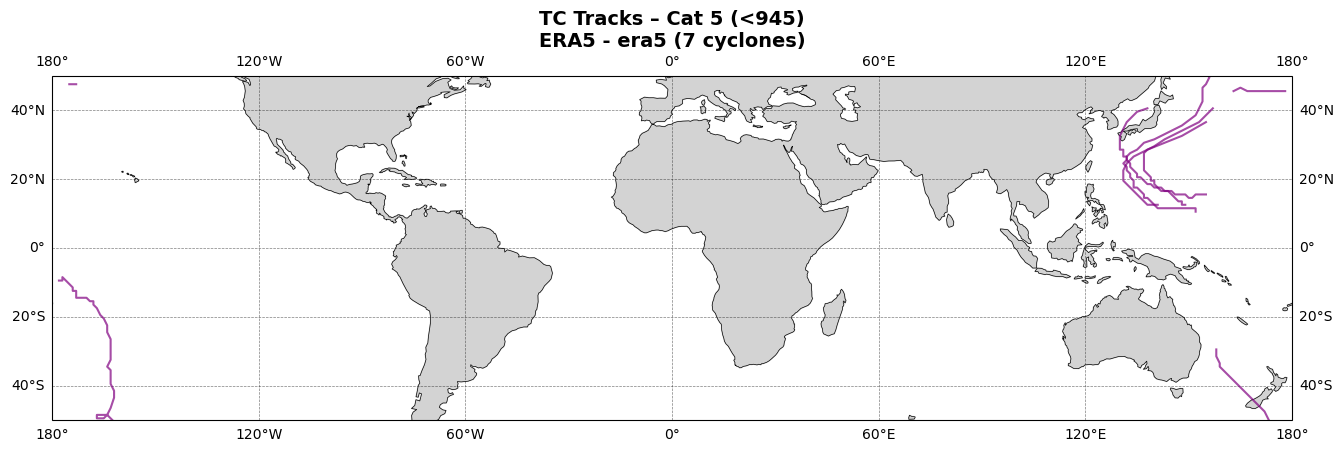

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/tracks_cat5_ERA5_era5_19790101_20150106.nc


In [ ]:
# OPZIONE 3: Solo Cat 5
plot_trajectories_colored(tc_data, config, category=5)
# → Salva: tracks_cat5_MODEL_EXP_DATE.pdf/nc

Using data from memory (fast)
Total TC observation points: 39,410
Computing KDE...
✓ Plot saved: /work/users/mccorda/tc_analysis2/Figures/density_scatter_ERA5_era5_19790101_20050106.pdf


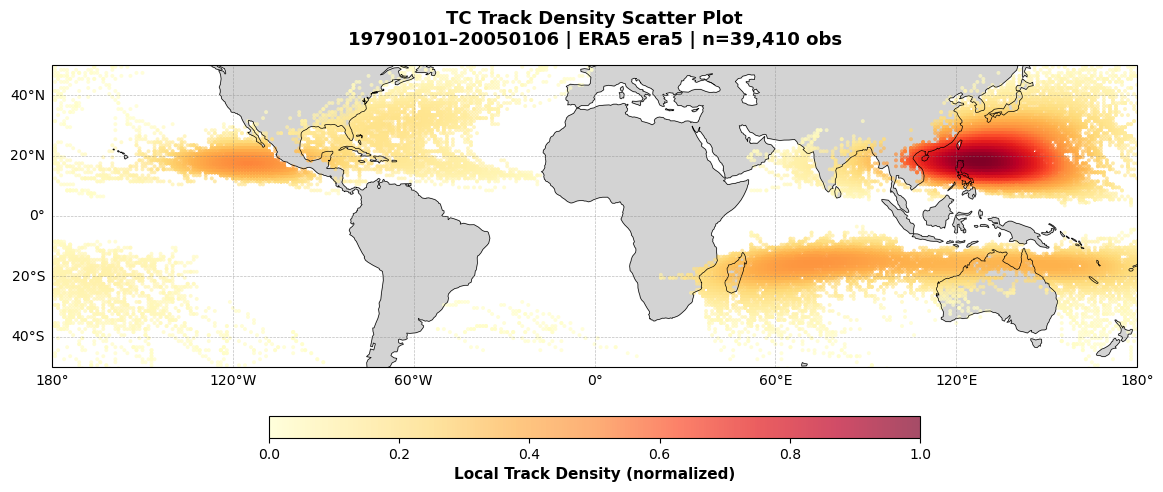

In [ ]:
plot_density_scatter(tc_data, config) 

Using data from memory (fast)
Total TC points: 63,864
Time period: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_ICON_historical-1990_19900101_20141231.pdf


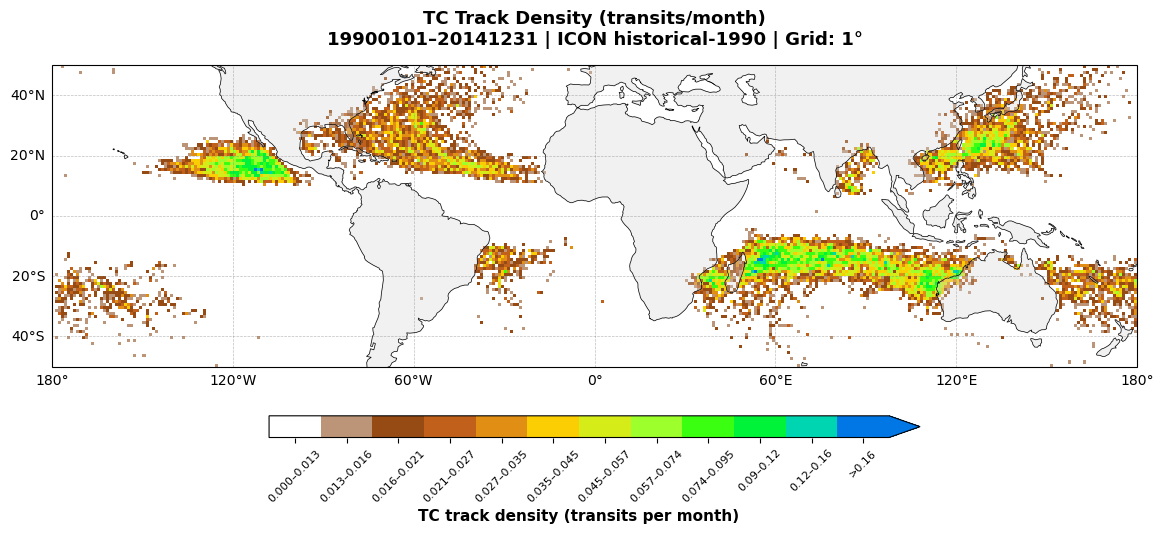

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_ICON_historical-1990_19900101_20141231.nc


In [12]:
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}
plot_track_density_grid(tc_data, plot_config, grid_size=1)

Using data from memory (fast)
Total TC points: 63,864
Time period: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_ICON_historical-1990_19900101_20141231.pdf


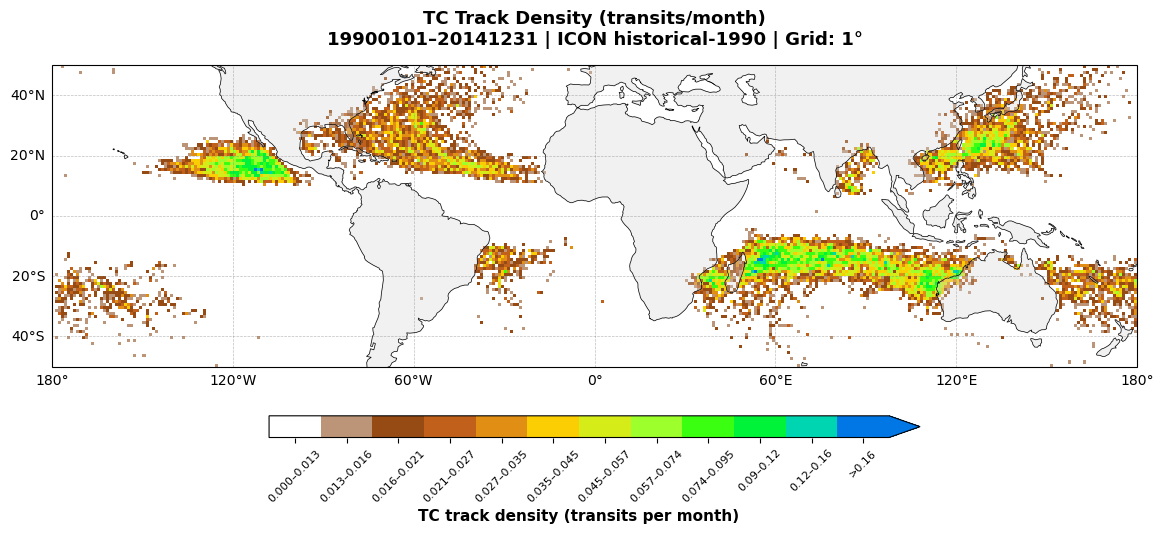

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_ICON_historical-1990_19900101_20141231.nc
Using data from memory (fast)
✓ 717 storms with peak category 3+ (slp)
Total TC points: 26,848
Time period: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat3plus_ICON_historical-1990_19900101_20141231.pdf


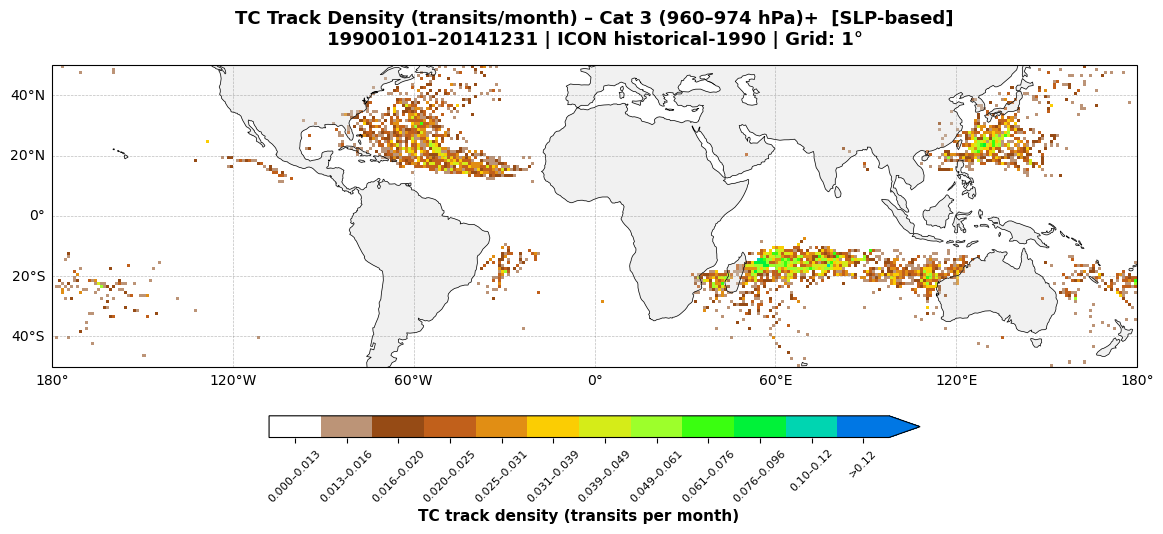

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat3plus_ICON_historical-1990_19900101_20141231.nc
Using data from memory (fast)
✓ 1835 storms with peak category 2- (slp)
Total TC points: 37,016
Time period: 300 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat2minus_ICON_historical-1990_19900101_20141231.pdf


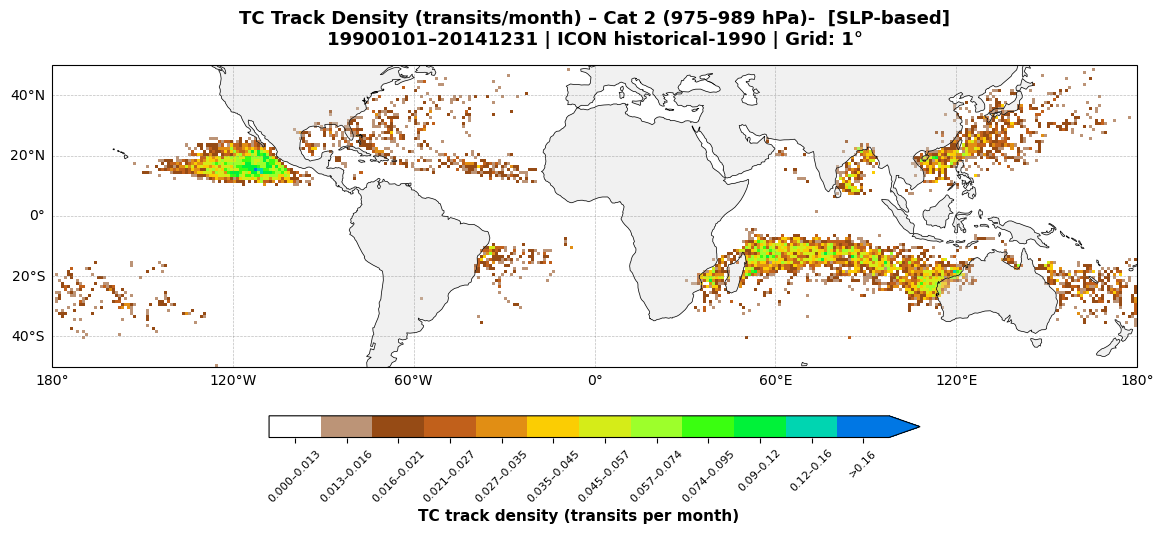

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat2minus_ICON_historical-1990_19900101_20141231.nc


In [13]:
# Plot di tutti i TC
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}
plot_track_density_grid(tc_data, plot_config, grid_size=1)

plot_track_density_grid(tc_data, plot_config, category= 3, grid_size=1)
plot_track_density_grid(tc_data, plot_config, category="2-", grid_size=1)

Using data from memory (fast)
✓ 364 storms with peak ≥ Cat 3 (960–974 hPa) (slp)
Total TC points: 12,993
Time period: 288 months
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat3plus_IFS-FESOM_historical-1990_19910101_20141231.pdf


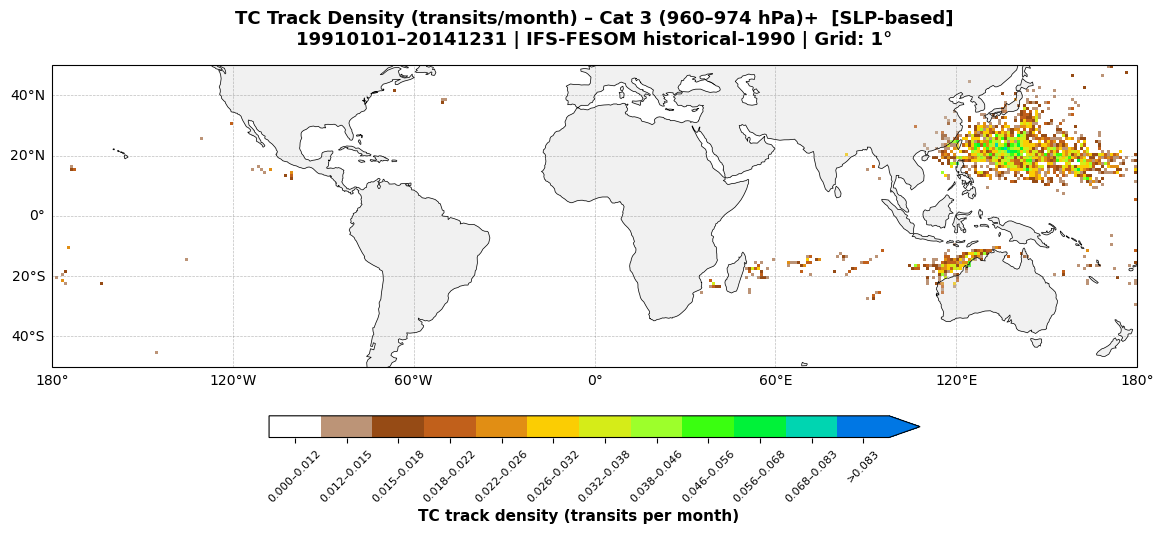

✓ NetCDF → /work/users/mccorda/tcs_stitch_csv/Figures/track_density_grid_slp_cat3plus_IFS-FESOM_historical-1990_19910101_20141231.nc


In [ ]:
# Solo Major Hurricanes (Cat 3+)
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}
 
plot_track_density_grid(tc_data, plot_config, category=3)

Using data from memory (fast)
Filtering for Cat 3 (960–974 hPa) and stronger...
✓ Found 451 storms with peak intensity ≥ Cat 3 (960–974 hPa)
Total TC observation points: 14,871
Time period: 433 months
Data range: 0.0023 - 0.09 transits/month
Colorbar range: 0.0100 - 0.10
Colorbar boundaries: [0.         0.01211528 0.01467799 0.01778279 0.02154435 0.02610157
 0.03162278 0.03831187 0.04641589 0.05623413 0.06812921 0.08254042
 0.1       ]
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat3plus.pdf


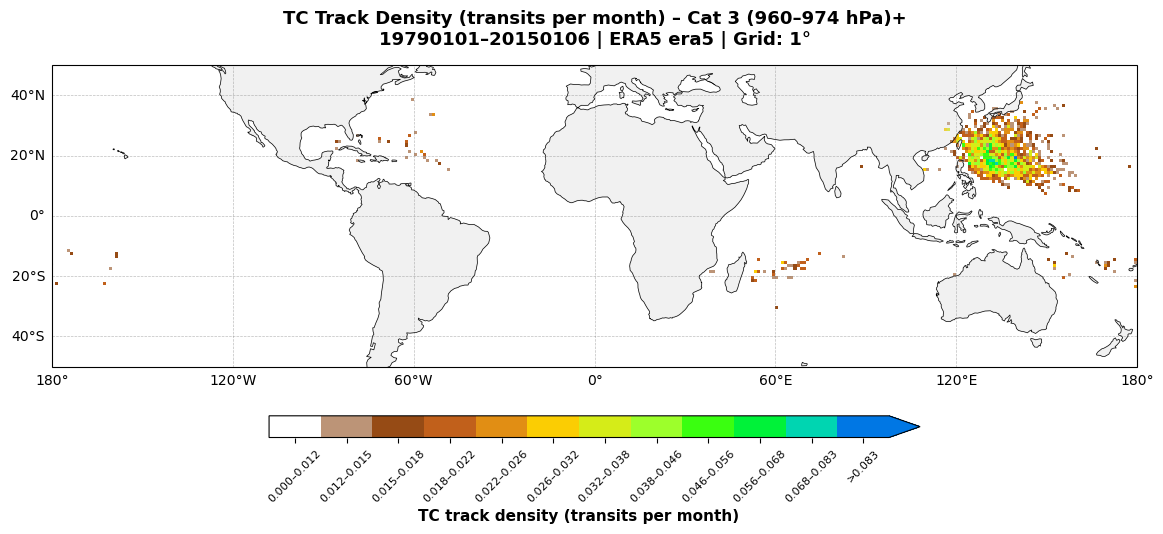

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat3plus.nc
  Grid dimensions: 100 lat × 360 lon
  Data variables: transits_per_month, count, transits_discrete


In [ ]:
# Solo Major Hurricanes (Cat 3+)
plot_track_density_grid(tc_data, config, category=3)

Using data from memory (fast)
Filtering for Cat 4 (945–959 hPa) and stronger...
✓ Found 107 storms with peak intensity ≥ Cat 4 (945–959 hPa)
Total TC observation points: 3,972
Time period: 433 months
Data range: 0.0023 - 0.05 transits/month
Colorbar range: 0.0100 - 0.05
Colorbar boundaries: [0.         0.0114353  0.0130766  0.01495349 0.01709976 0.01955409
 0.02236068 0.0255701  0.02924018 0.03343702 0.03823622 0.04372426
 0.05      ]
✓ PDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat4plus.pdf


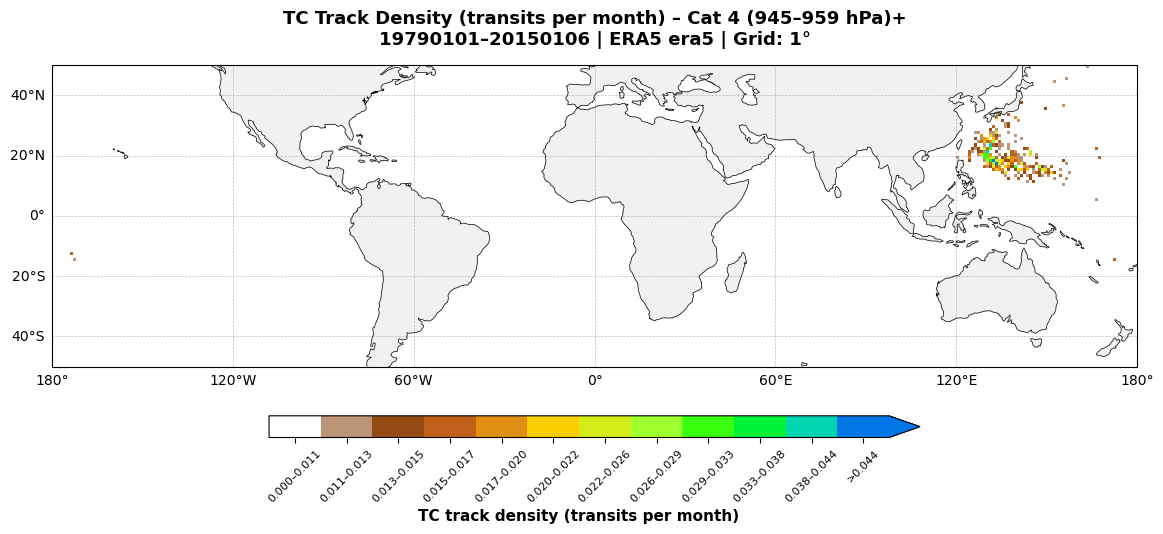

✓ NetCDF saved to: /work/users/mccorda/tc_analysis2/Figures/track_density_grid_ERA5_era5_19790101_20150106_cat4plus.nc
  Grid dimensions: 100 lat × 360 lon
  Data variables: transits_per_month, count, transits_discrete


In [ ]:
# Cat 4 plus
plot_track_density_grid(tc_data, config, grid_size=1, category=4)

Using data from memory (fast)

Points per category:
  Cat 0: 5,381 points
  Cat 1: 35,550 points
  Cat 2: 12,309 points
  Cat 3: 3,448 points
  Cat 4: 505 points
  Cat 5: 23 points
✓ 6-panel plot saved: /work/users/mccorda/tc_analysis2/Figures/density_scatter_by_category_ERA5_era5_19790101_20150106.pdf


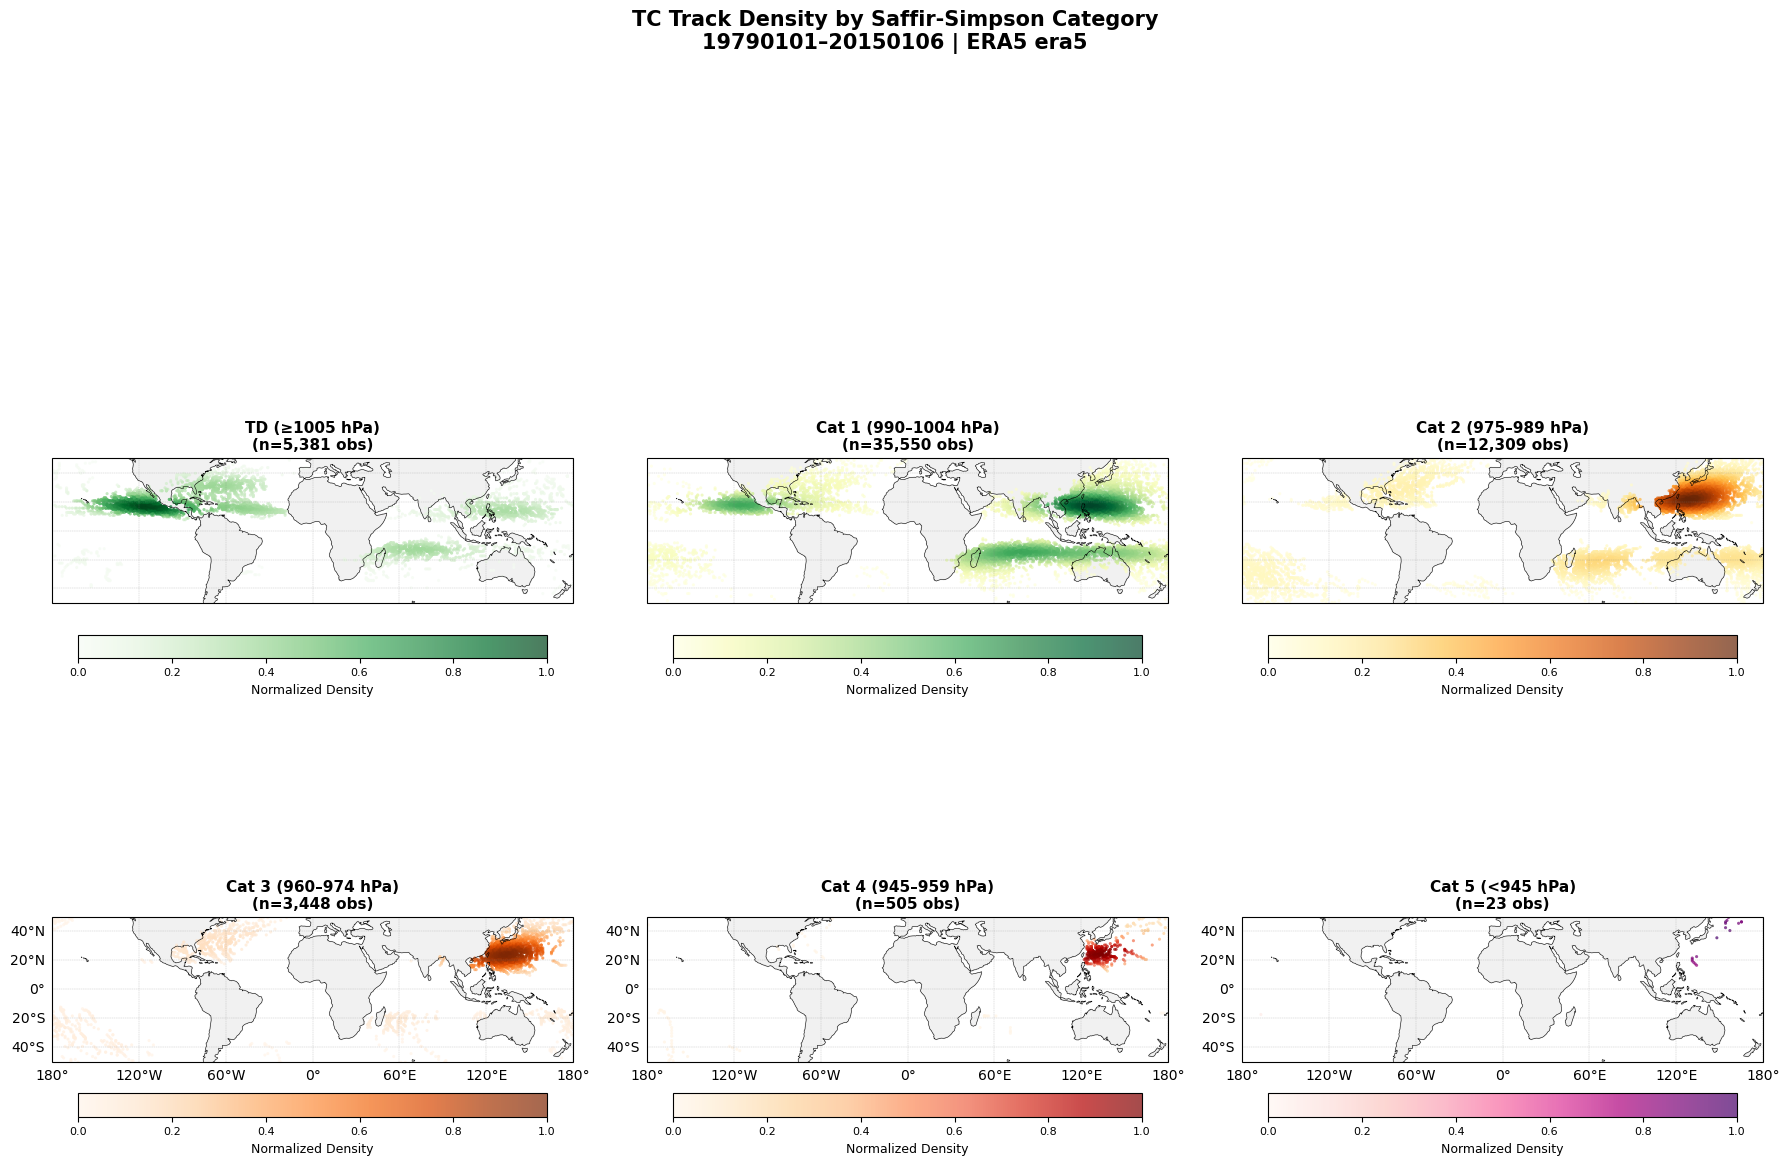

In [ ]:
plot_density_scatter_by_category(tc_data, config) 

Using data from memory (fast)
Storms: 2201  |  mean 6.1 d  | median 5.2 d  |  max 23.5 d
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/tc_duration_IFS-FESOM_historical-1990_19900101_20141231.pdf


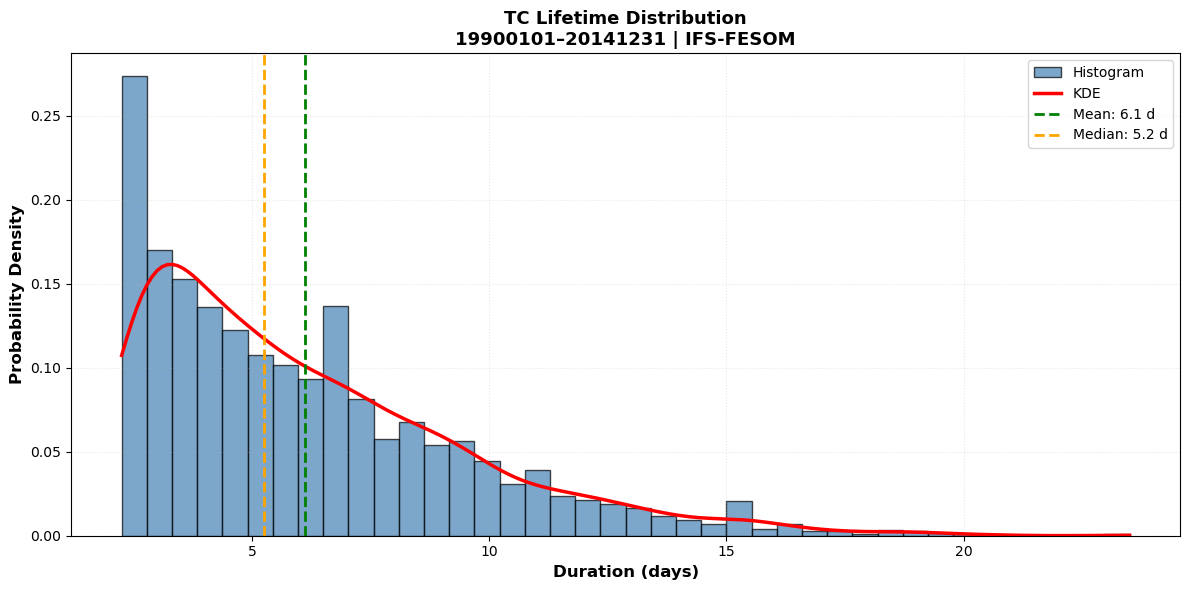

In [15]:
# Duration distribution
plot_config = dict(config)
plot_config['dataset'] = config['datasets'][0]  # {'model': 'IFS-FESOM', 'exp': 'historical-1990', ...}

plot_tc_duration_distribution(tc_data, plot_config)

Computing TC duration statistics from memory...
Using data from memory (fast)

TC DURATION STATISTICS
Total cyclones: 2484
Mean duration: 5.5 days
Median duration: 4.8 days
Min duration: 2.2 days (54 hours)
Max duration: 23.0 days
Std deviation: 2.8 days


✓ Duration distribution saved: /work/users/mccorda/tc_analysis2/Figures/tc_duration_distribution_ERA5_era5_19790101_20150106.pdf


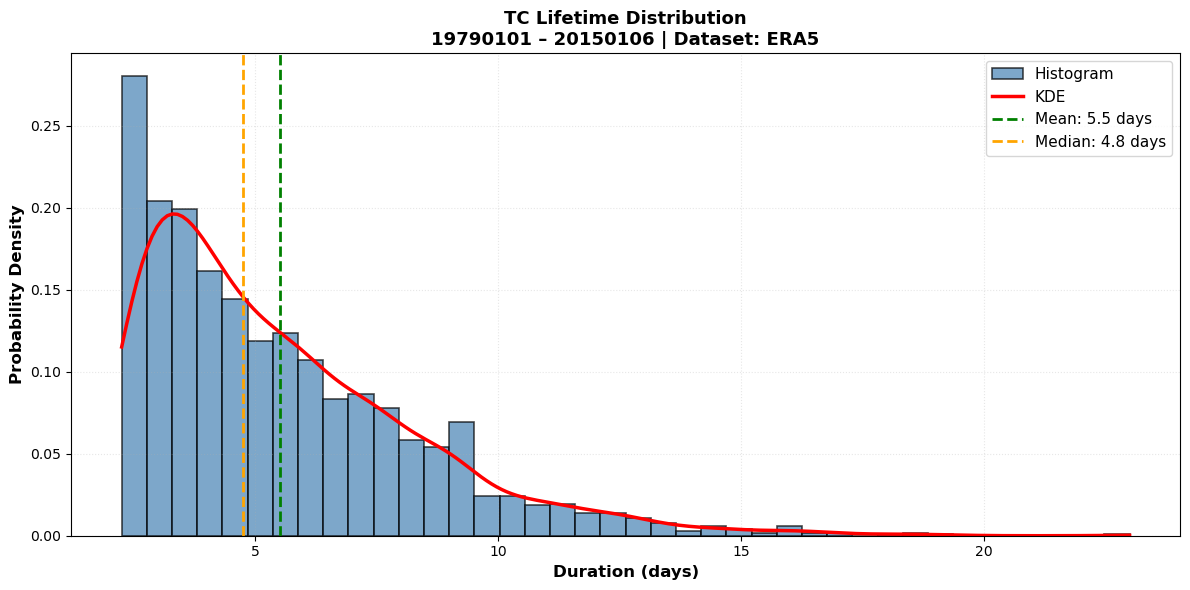

In [ ]:
# Duration distribution
plot_tc_duration_distribution(tc_data, config)

Using data from memory (fast)
✓ PDF  → /work/users/mccorda/tcs_stitch_csv/Figures/tc_duration_by_cat_slp_IFS-FESOM_historical-1990_19910101_20141231.pdf


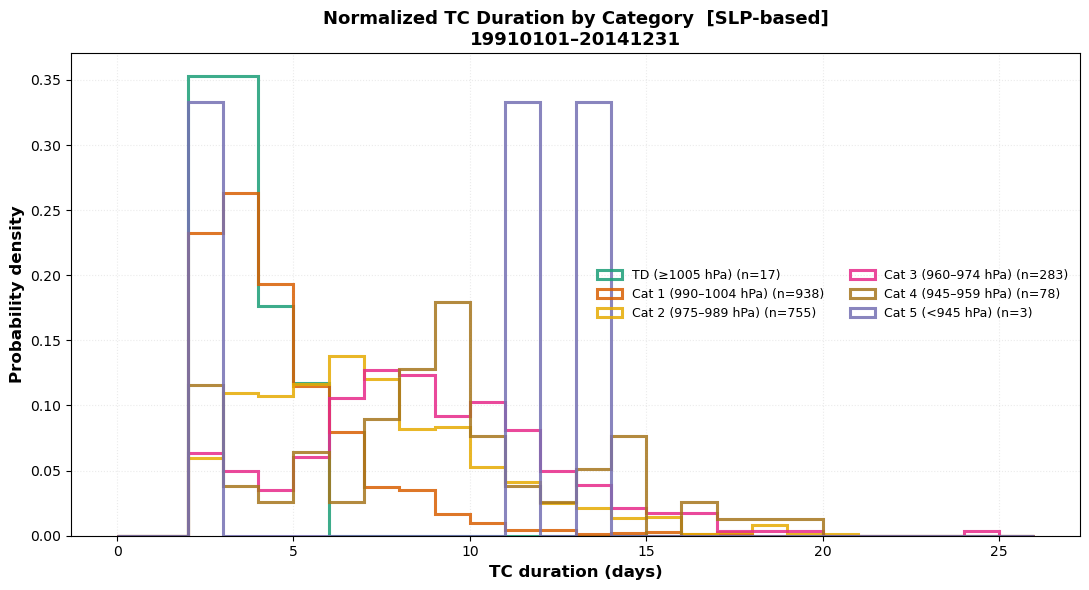

In [ ]:
# Duration by category (normalized)
plot_tc_duration_by_category(tc_data, plot_config)

Computing TC duration by category from memory...
Using data from memory (fast)

TC count per category:
  Cat 0: 29 storms, mean duration: 3.5 days
  Cat 1: 1183 storms, mean duration: 4.2 days
  Cat 2: 821 storms, mean duration: 6.0 days
  Cat 3: 344 storms, mean duration: 7.7 days
  Cat 4: 100 storms, mean duration: 9.1 days
  Cat 5: 7 storms, mean duration: 7.9 days
✓ Normalized duration histogram saved: /work/users/mccorda/tc_analysis2/Figures/tc_duration_normalized_by_category_ERA5_era5_19790101_20150106.pdf


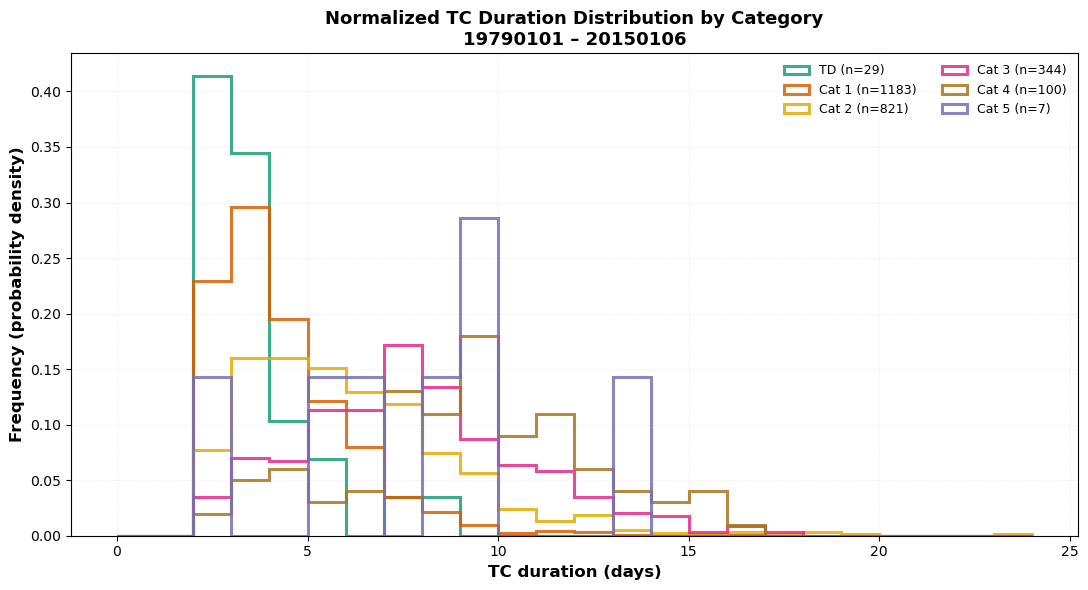

In [ ]:
# Duration by category (normalized)
plot_tc_duration_by_category(tc_data, config)

Using data from memory (fast)
Period: 1990–2014  (25 yr)
NH total: 47.6/yr   SH total: 48.4/yr
  North Atlantic: 16.9
  East Pacific: 12.4
  West Pacific: 16.0
  North Indian: 2.4
  South Indian: 30.4
  South Pacific: 13.8
  South Atlantic: 4.1
✓ Doughnut → /work/users/mccorda/tcs_stitch_csv/Figures/tc_doughnut_slp_ICON_historical-1990_19900101_20141231.pdf


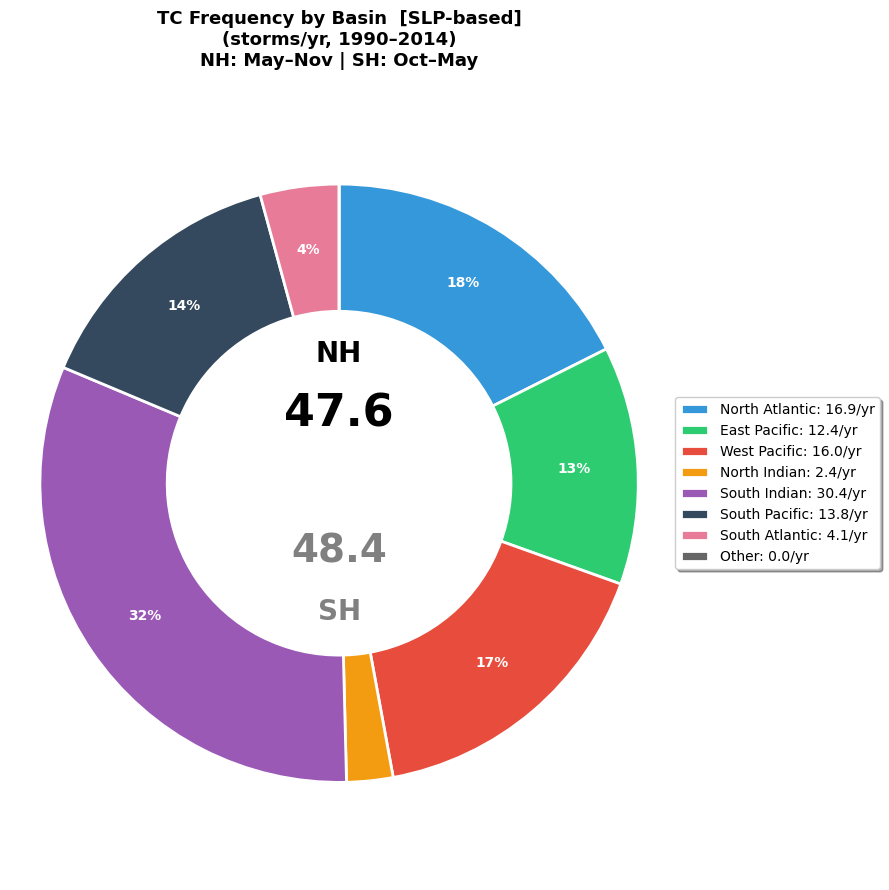


Basin                  This study   Roberts+20     Diff
-------------------------------------------------------
North Atlantic               16.9         12.5      4.4
East Pacific                 12.4         16.0     -3.6
West Pacific                 16.0         25.0     -9.0
North Indian                  2.4          5.5     -3.1
South Indian                 30.4         10.0     20.4
South Pacific                13.8          4.5      9.3
South Atlantic                4.1          nan      nan
Other                         0.0          nan      nan
✓ Comparison → /work/users/mccorda/tcs_stitch_csv/Figures/tc_freq_comparison_slp_ICON_historical-1990_19900101_20141231.pdf


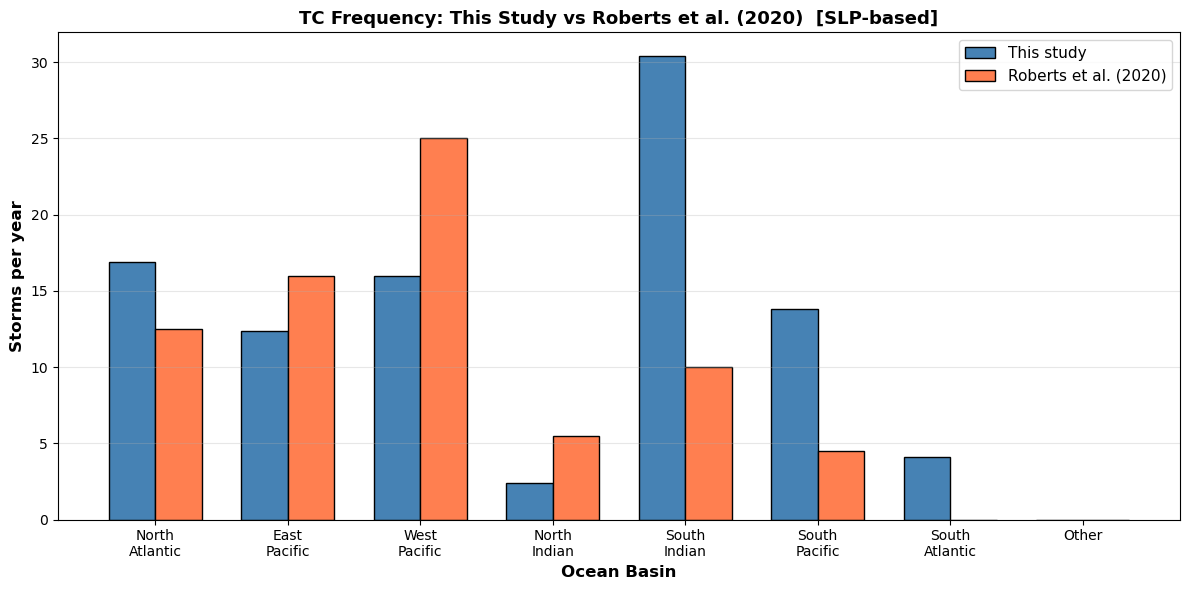

Using data from memory (fast)
✓ 717 storms with peak category Cat 3 (960–974 hPa)+ (slp)
Period: 1990–2014  (25 yr)
NH total: 13.5/yr   SH total: 13.4/yr
  North Atlantic: 7.2
  East Pacific: 0.5
  West Pacific: 5.6
  North Indian: 0.2
  South Indian: 8.2
  South Pacific: 4.1
  South Atlantic: 1.1
✓ Doughnut → /work/users/mccorda/tcs_stitch_csv/Figures/tc_doughnut_slp_cat3plus_ICON_historical-1990_19900101_20141231.pdf


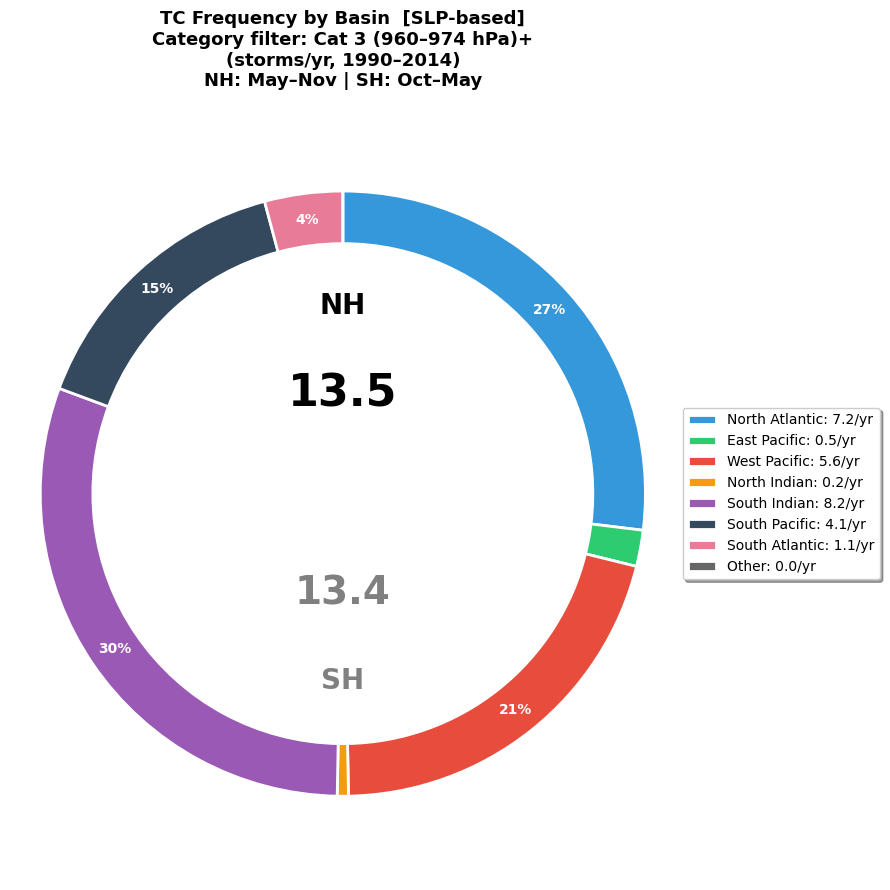


Basin                  This study   Roberts+20     Diff
-------------------------------------------------------
North Atlantic                7.2         12.5     -5.3
East Pacific                  0.5         16.0    -15.5
West Pacific                  5.6         25.0    -19.4
North Indian                  0.2          5.5     -5.3
South Indian                  8.2         10.0     -1.8
South Pacific                 4.1          4.5     -0.4
South Atlantic                1.1          nan      nan
Other                         0.0          nan      nan
✓ Comparison → /work/users/mccorda/tcs_stitch_csv/Figures/tc_freq_comparison_slp_cat3plus_ICON_historical-1990_19900101_20141231.pdf


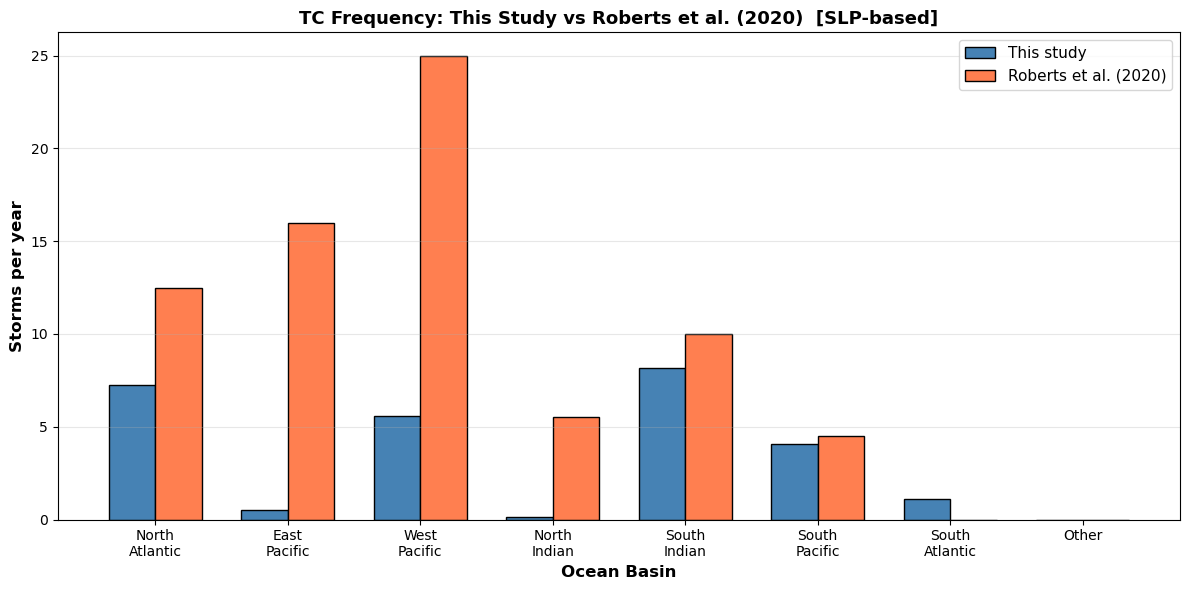

Using data from memory (fast)
✓ 1835 storms with peak category Cat 2 (975–989 hPa)- (slp)
Period: 1990–2014  (25 yr)
NH total: 34.1/yr   SH total: 35.0/yr
  North Atlantic: 9.6
  East Pacific: 11.8
  West Pacific: 10.4
  North Indian: 2.2
  South Indian: 22.3
  South Pacific: 9.8
  South Atlantic: 3.0
✓ Doughnut → /work/users/mccorda/tcs_stitch_csv/Figures/tc_doughnut_slp_cat2minus_ICON_historical-1990_19900101_20141231.pdf


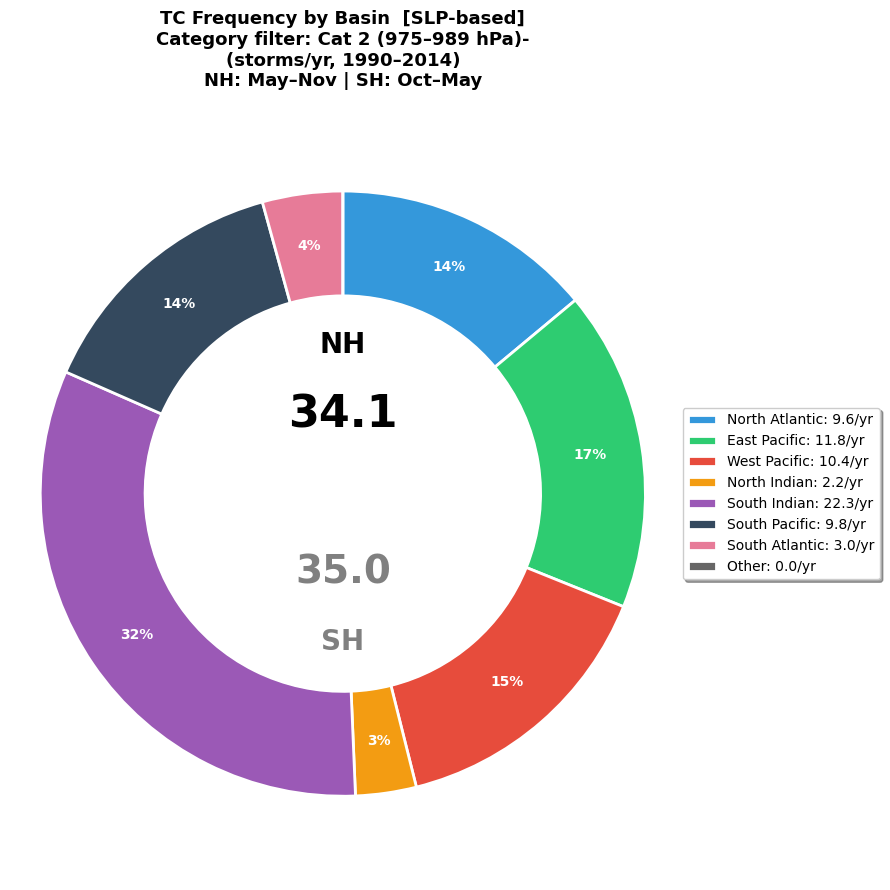


Basin                  This study   Roberts+20     Diff
-------------------------------------------------------
North Atlantic                9.6         12.5     -2.9
East Pacific                 11.8         16.0     -4.2
West Pacific                 10.4         25.0    -14.6
North Indian                  2.2          5.5     -3.3
South Indian                 22.3         10.0     12.3
South Pacific                 9.8          4.5      5.3
South Atlantic                3.0          nan      nan
Other                         0.0          nan      nan
✓ Comparison → /work/users/mccorda/tcs_stitch_csv/Figures/tc_freq_comparison_slp_cat2minus_ICON_historical-1990_19900101_20141231.pdf


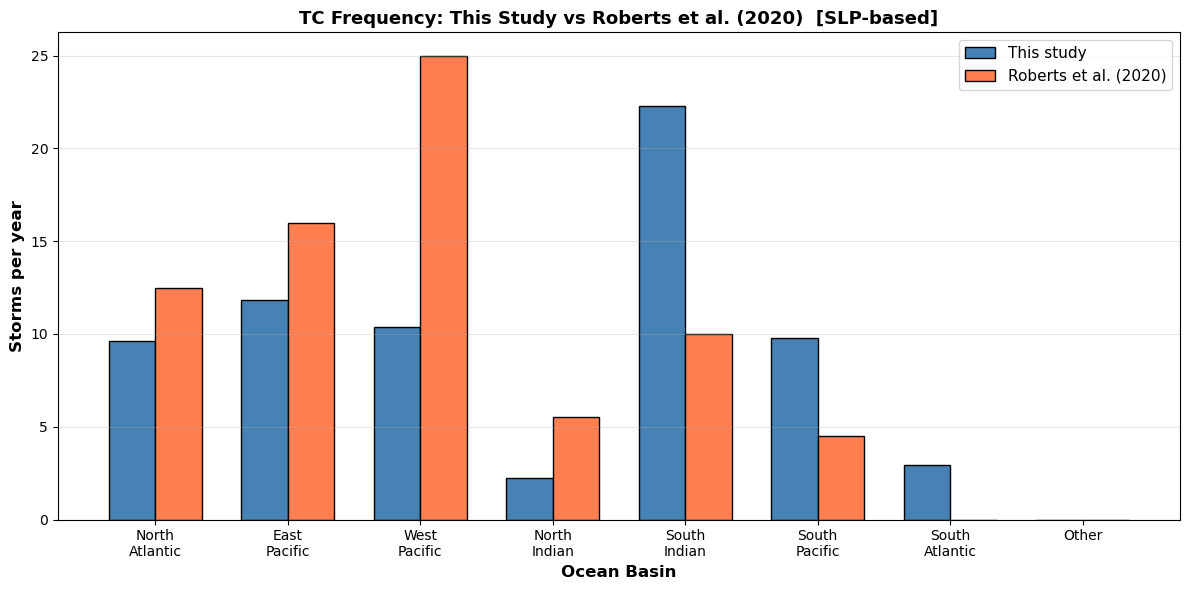

In [14]:
# Basin doughnut + comparison
plot_tc_basin_doughnut(tc_data, plot_config)

plot_tc_basin_doughnut(tc_data, plot_config, category="3+")

plot_tc_basin_doughnut(tc_data, plot_config, category="2-")

Computing basin frequencies from memory...
Using data from memory (fast)
Period: 1979-2014 (36 years)

Annual frequencies (storms/year):
  NH total: 41.2
  SH total: 24.2
    North Atlantic: 8.4
    East Pacific: 8.2
    West Pacific: 22.2
    North Indian: 2.4
    South Indian: 14.5
    South Pacific: 9.8
✓ Doughnut chart saved: /work/users/mccorda/tc_analysis2/Figures/tc_doughnut_frequency_ERA5_era5_19790101_20150106.pdf


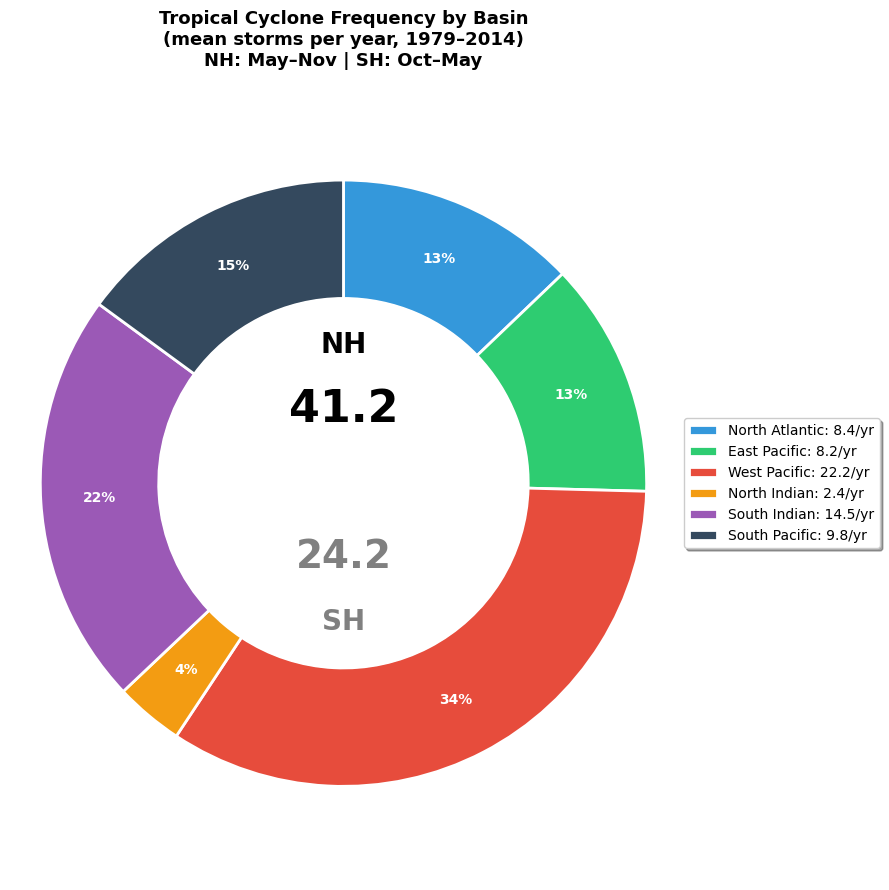


COMPARISON WITH ROBERTS ET AL. (2020)
Basin                This study         Roberts et al.     Difference     
----------------------------------------------------------------------
North Atlantic                    8.4             12.5     -4.1 (-33%)
East Pacific                      8.2             16.0     -7.8 (-49%)
West Pacific                     22.2             25.0     -2.8 (-11%)
North Indian                      2.4              5.5     -3.1 (-57%)
South Indian                     14.5             10.0      4.5 (+45%)
South Pacific                     9.8              4.5      5.3 (+117%)
----------------------------------------------------------------------
NH Total                         41.2             59.0    -17.8 (-30%)
SH Total                         24.2             14.5      9.8 (+67%)
✓ Comparison chart saved: /work/users/mccorda/tc_analysis2/Figures/tc_frequency_comparison_ERA5_era5_19790101_20150106.pdf


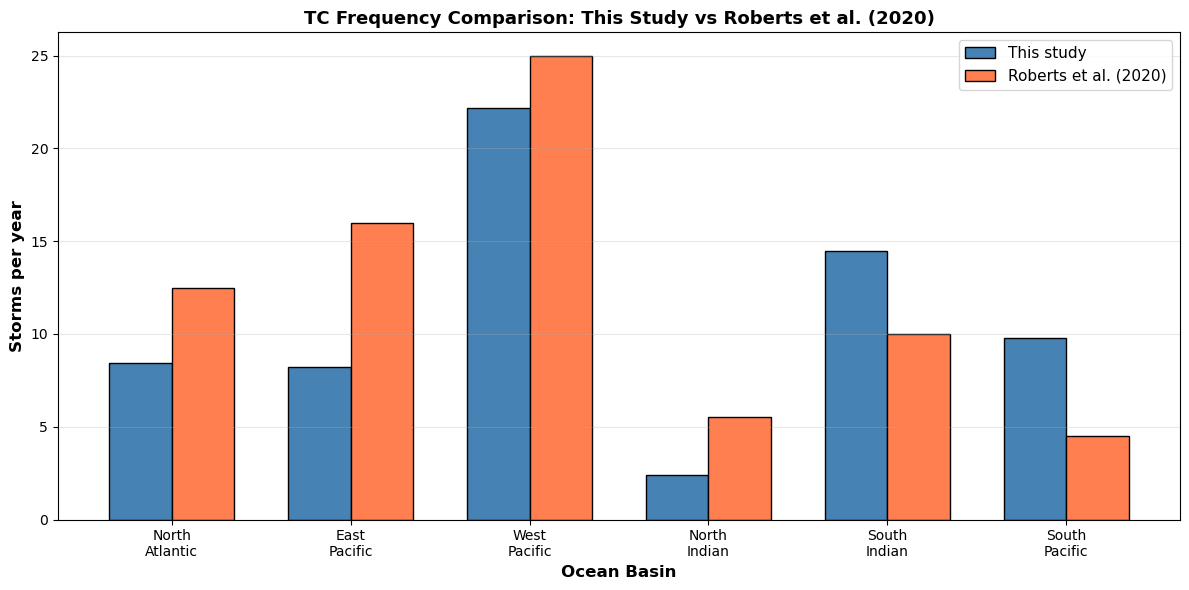

✓ Basin analysis complete!


In [ ]:
# Basin doughnut + comparison
plot_tc_basin_doughnut(tc_data, config)


LOADING TC DATA INTO MEMORY
Source: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19910101_20141231.txt
  Parsed 41,189 observations from file
  Converting to numpy arrays...
  Building trajectory list...
✓ Data loaded successfully!
  Observations: 41,189
  Storms: 1789


TC DATA SUMMARY
Source file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19910101_20141231.txt
Total observations: 41,189
Total storms: 1789

Time period:
  Start: 1991-01
  End: 2014-12
  Duration: 288 months

Data ranges:
  SLP: 93621.8 - 101968.6 Pa
  Wind: 2.4 - 32.6 m/s
  Latitude: -67.5° to 66.5°
  Longitude: 0.0° to 359.0°

Memory usage:
  Total: 4.09 MB

Trajectory structure:
  Type: LIST (not dict)
  Length: 1789
  First storm ID: '0'
  Last storm ID: '1788'

✓ PDF → /work/users/mccorda/tcs_stitch_csv/Figures/tc_count_comparison_IFS-FESOM_vs_ERA5_1991_2014.pdf


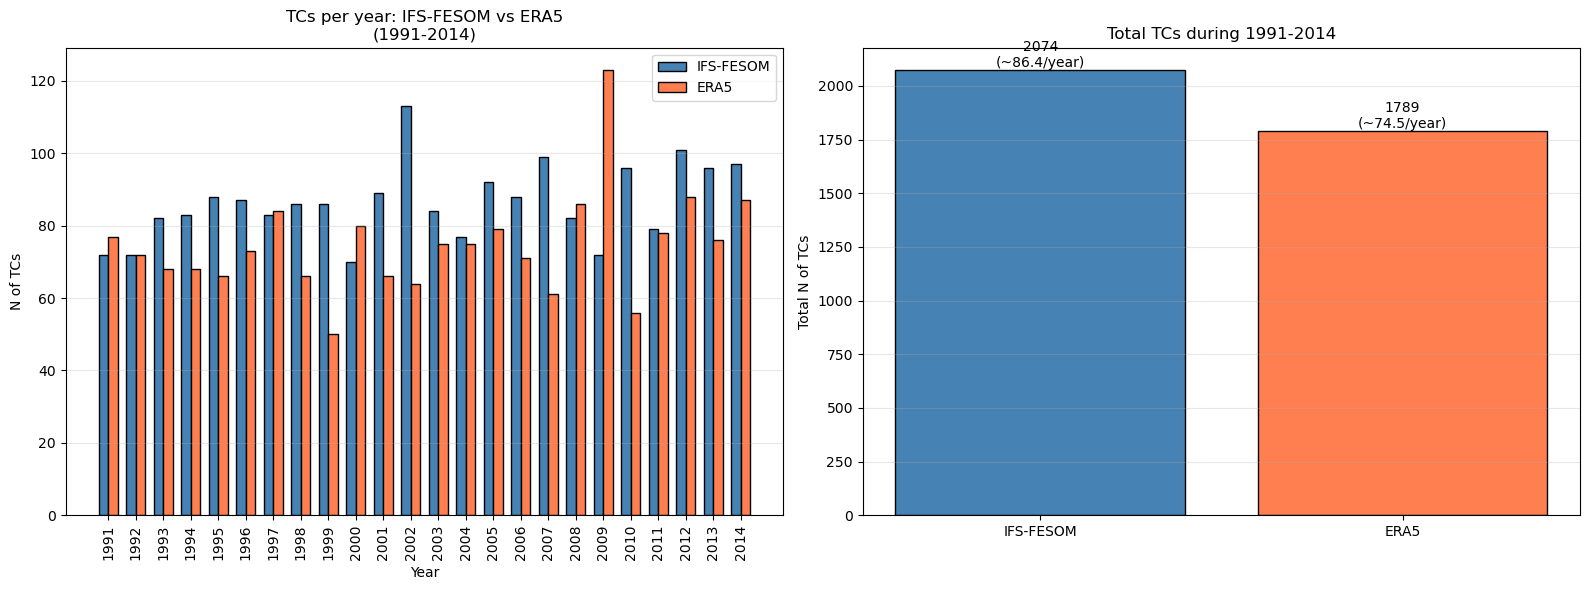

In [ ]:
# ===========================================
# 7. CONFRONTO NUMERO TC: IFS-FESOM vs ERA5
# ===========================================
from tc_data_manager import TCDataManager
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Periodo di confronto ---
compare_start_year = 1991
compare_end_year   = 2014

# --- Path alle tracce ---
ifs_fesom_data = tc_data  # già caricato in memoria (celle precedenti)
era5_track_file = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19910101_20141231.txt"

era5_data = TCDataManager(era5_track_file)
era5_data.summary()

def count_storms_per_year(trajectories, start_year, end_year):
    """Count unique storms per year, based on the first timestep of each track."""
    counts = {y: 0 for y in range(start_year, end_year + 1)}
    for storm in trajectories:
        y0 = int(storm['year'][0])
        if start_year <= y0 <= end_year:
            counts[y0] += 1
    return counts

counts_ifs  = count_storms_per_year(ifs_fesom_data.trajectories, compare_start_year, compare_end_year)
counts_era5 = count_storms_per_year(era5_data.trajectories,      compare_start_year, compare_end_year)

years    = list(range(compare_start_year, compare_end_year + 1))
ifs_vals  = [counts_ifs[y]  for y in years]
era5_vals = [counts_era5[y] for y in years]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Pannello 1: conteggio annuale affiancato ---
x = np.arange(len(years))
w = 0.35
axes[0].bar(x - w/2, ifs_vals,  w, label='IFS-FESOM', color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, era5_vals, w, label='ERA5',       color='coral',    edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=90)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('N of TCs')
axes[0].set_title(f'TCs per year: IFS-FESOM vs ERA5\n({compare_start_year}-{compare_end_year})')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# --- Pannello 2: totali/medie a confronto ---
totals = [sum(ifs_vals), sum(era5_vals)]
means  = [np.mean(ifs_vals), np.mean(era5_vals)]
labels = ['IFS-FESOM', 'ERA5']
axes[1].bar(labels, totals, color=['steelblue', 'coral'], edgecolor='black')
for i, (t, m) in enumerate(zip(totals, means)):
    axes[1].text(i, t, f'{t}\n(~{m:.1f}/year)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Total N of TCs')
axes[1].set_title(f'Total TCs during {compare_start_year}-{compare_end_year}')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()

# --- Salvataggio nella cartella Figures di IFS-FESOM ---
plotdir = config['paths']['plotdir']
os.makedirs(plotdir, exist_ok=True)
outpath = os.path.join(plotdir, f"tc_count_comparison_IFS-FESOM_vs_ERA5_{compare_start_year}_{compare_end_year}.pdf")
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print(f"✓ PDF → {outpath}")
plt.show()

Loading ERA5...

LOADING TC DATA INTO MEMORY
Source: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19910101_20141231.txt
  Parsed 41,189 observations from file
  Converting to numpy arrays...


  Building trajectory list...
✓ Data loaded successfully!
  Observations: 41,189
  Storms: 1789


TC DATA SUMMARY
Source file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19910101_20141231.txt
Total observations: 41,189
Total storms: 1789

Time period:
  Start: 1991-01
  End: 2014-12
  Duration: 288 months

Data ranges:
  SLP: 93621.8 - 101968.6 Pa
  Wind: 2.4 - 32.6 m/s
  Latitude: -67.5° to 66.5°
  Longitude: 0.0° to 359.0°

Memory usage:
  Total: 4.09 MB

Trajectory structure:
  Type: LIST (not dict)
  Length: 1789
  First storm ID: '0'
  Last storm ID: '1788'


Loading IBTrACS...

LOADING TC DATA INTO MEMORY
Source: /home/mccorda/work/tc_analysis_ibtracks/ibtracs_1979_2014_custom.txt
  Parsed 103,408 observations from file
  Converting to numpy arrays...
  Building trajectory list...
✓ Data loaded successfully!
  Observations: 103,408
  Storms: 3302


TC DATA SUMMARY
Source file: /home/mccorda/work/tc_analysis_ibtracks/ibtracs_1979_2014_custom.txt
Total obs

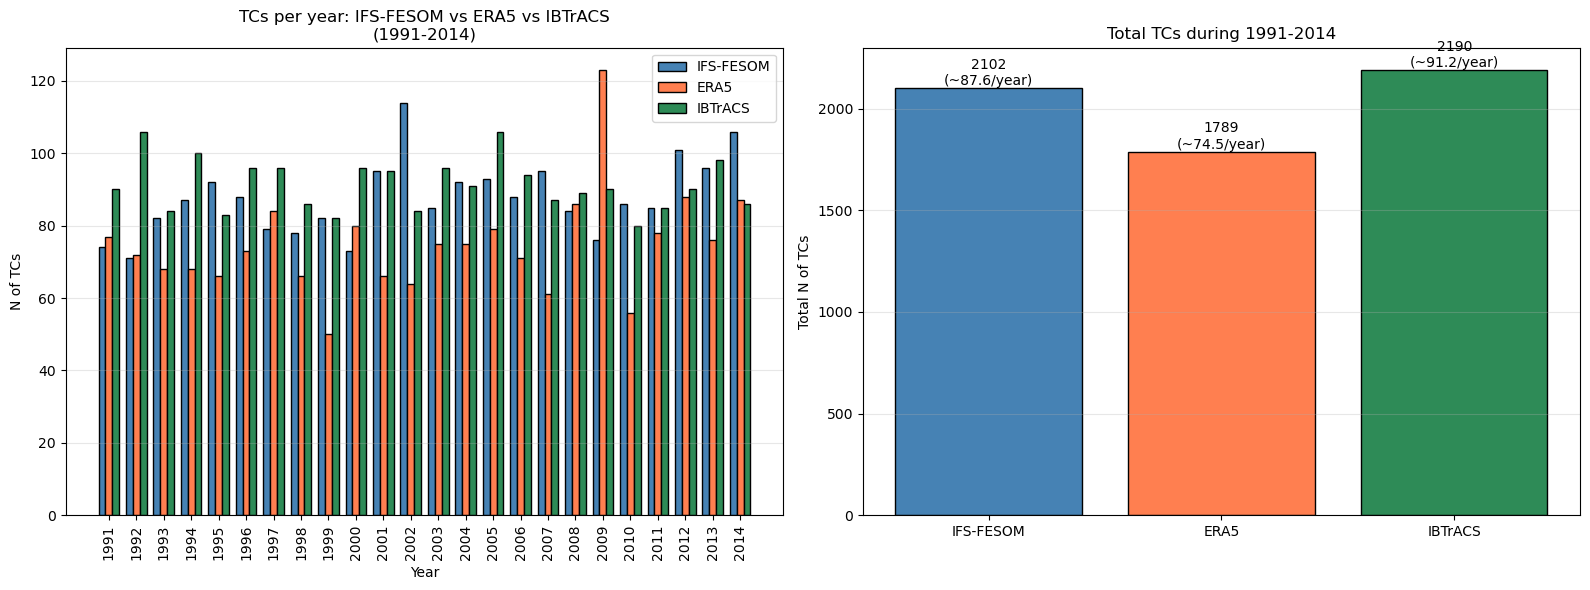

In [11]:
# ===========================================
# 7. CONFRONTO NUMERO TC:
#    IFS-FESOM vs ERA5 vs IBTrACS
# ===========================================

from tc_data_manager import TCDataManager
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Periodo di confronto ---
compare_start_year = 1991
compare_end_year   = 2014

# ============================================================
# PATH
# ============================================================

# IFS-FESOM: già caricato in memoria
ifs_fesom_data = tc_data

# ERA5
era5_track_file = (
    "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/"
    "tempest_tracks_tot_19910101_20141231.txt"
)

# IBTrACS
ibtracs_track_file = (
    "/home/mccorda/work/tc_analysis_ibtracks/"
    "ibtracs_1979_2014_custom.txt"
)

# ============================================================
# CARICAMENTO
# ============================================================

print("Loading ERA5...")
era5_data = TCDataManager(era5_track_file)
era5_data.summary()

print("\nLoading IBTrACS...")
ibtracs_data = TCDataManager(ibtracs_track_file)
ibtracs_data.summary()

# ============================================================
# COUNT STORMS PER YEAR
# ============================================================

def count_storms_per_year(trajectories, start_year, end_year):
    """
    Count unique storms per year, assigning each storm
    to the year of its first timestep.
    """
    counts = {y: 0 for y in range(start_year, end_year + 1)}

    for storm in trajectories:
        if len(storm["year"]) == 0:
            continue

        y0 = int(storm["year"][0])

        if start_year <= y0 <= end_year:
            counts[y0] += 1

    return counts


counts_ifs = count_storms_per_year(
    ifs_fesom_data.trajectories,
    compare_start_year,
    compare_end_year
)

counts_era5 = count_storms_per_year(
    era5_data.trajectories,
    compare_start_year,
    compare_end_year
)

counts_ibtracs = count_storms_per_year(
    ibtracs_data.trajectories,
    compare_start_year,
    compare_end_year
)

# ============================================================
# ARRAYS
# ============================================================

years = list(range(compare_start_year, compare_end_year + 1))

ifs_vals = [counts_ifs[y] for y in years]
era5_vals = [counts_era5[y] for y in years]
ibtracs_vals = [counts_ibtracs[y] for y in years]

# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ------------------------------------------------------------
# PANNELLO 1: TC PER ANNO
# ------------------------------------------------------------

x = np.arange(len(years))
w = 0.25

axes[0].bar(
    x - w,
    ifs_vals,
    w,
    label="IFS-FESOM",
    color="steelblue",
    edgecolor="black"
)

axes[0].bar(
    x,
    era5_vals,
    w,
    label="ERA5",
    color="coral",
    edgecolor="black"
)

axes[0].bar(
    x + w,
    ibtracs_vals,
    w,
    label="IBTrACS",
    color="seagreen",
    edgecolor="black"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=90)
axes[0].set_xlabel("Year")
axes[0].set_ylabel("N of TCs")
axes[0].set_title(
    f"TCs per year: IFS-FESOM vs ERA5 vs IBTrACS\n"
    f"({compare_start_year}-{compare_end_year})"
)
axes[0].legend()
axes[0].grid(alpha=0.3, axis="y")

# ------------------------------------------------------------
# PANNELLO 2: TOTALI / MEDIE
# ------------------------------------------------------------

totals = [
    sum(ifs_vals),
    sum(era5_vals),
    sum(ibtracs_vals)
]

means = [
    np.mean(ifs_vals),
    np.mean(era5_vals),
    np.mean(ibtracs_vals)
]

labels = ["IFS-FESOM", "ERA5", "IBTrACS"]

axes[1].bar(
    labels,
    totals,
    color=["steelblue", "coral", "seagreen"],
    edgecolor="black"
)

for i, (total, mean) in enumerate(zip(totals, means)):
    axes[1].text(
        i,
        total,
        f"{total}\n(~{mean:.1f}/year)",
        ha="center",
        va="bottom",
        fontsize=10
    )

axes[1].set_ylabel("Total N of TCs")
axes[1].set_title(
    f"Total TCs during {compare_start_year}-{compare_end_year}"
)
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()

# ============================================================
# SALVATAGGIO
# ============================================================

plotdir = config["paths"]["plotdir"]
os.makedirs(plotdir, exist_ok=True)

outpath = os.path.join(
    plotdir,
    f"tc_count_comparison_IFS-FESOM_ERA5_IBTrACS_"
    f"{compare_start_year}_{compare_end_year}.pdf"
)

plt.savefig(
    outpath,
    dpi=300,
    bbox_inches="tight"
)

print(f"✓ PDF → {outpath}")

plt.show()


LOADING TC DATA INTO MEMORY
Source: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19900101_20141231.txt
  Parsed 43,254 observations from file
  Converting to numpy arrays...
  Building trajectory list...
✓ Data loaded successfully!
  Observations: 43,254
  Storms: 1877


TC DATA SUMMARY
Source file: /work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19900101_20141231.txt
Total observations: 43,254
Total storms: 1877

Time period:
  Start: 1990-01
  End: 2014-12
  Duration: 300 months

Data ranges:
  SLP: 93621.8 - 101968.6 Pa
  Wind: 2.4 - 32.6 m/s
  Latitude: -67.5° to 66.5°
  Longitude: 0.0° to 359.0°

Memory usage:
  Total: 4.29 MB

Trajectory structure:
  Type: LIST (not dict)
  Length: 1877
  First storm ID: '0'
  Last storm ID: '1876'


STATISTICAL COMPARISON: IFS-FESOM vs ERA5 (1990-2014)
Mean bias (IFS - ERA5):     +12.96 storms/year
RMSE:                       22.18 storms/year
Spearman correlation:       rho=-0.02, p=0.9351
Wilcoxon 

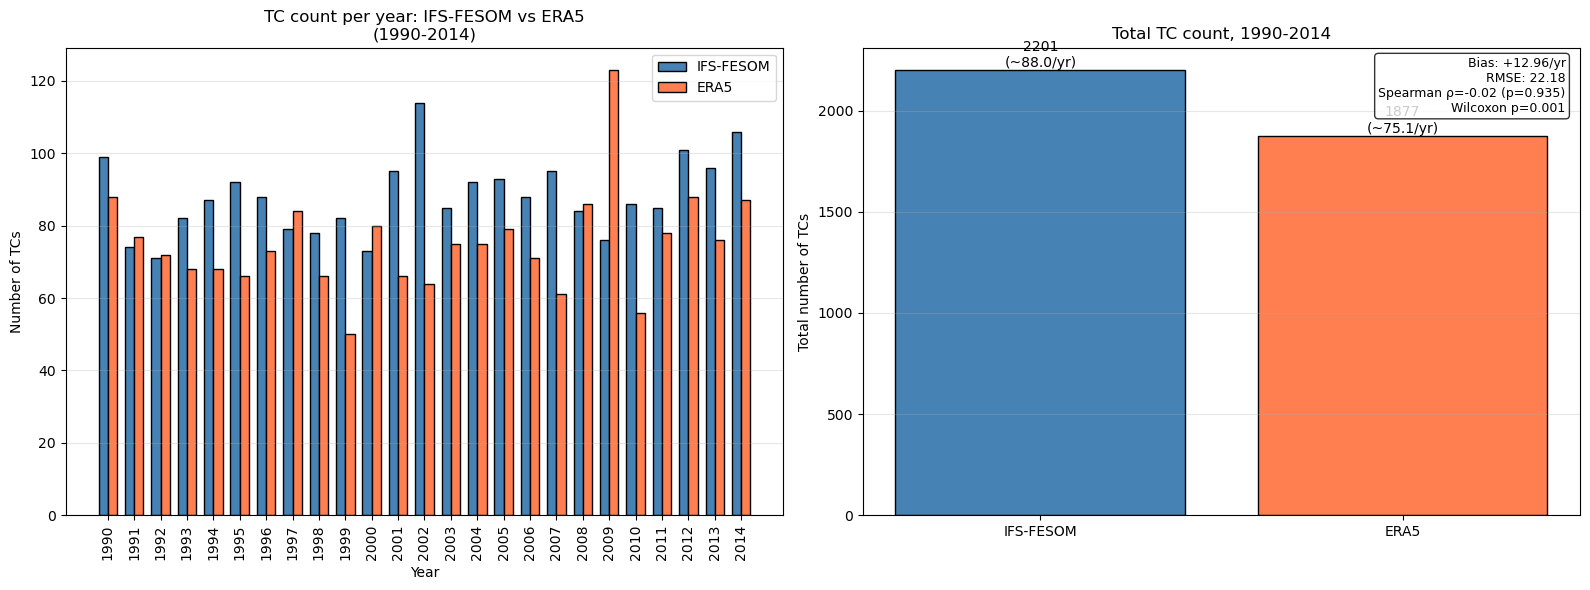

In [15]:
# ===========================================
# 7. TC COUNT COMPARISON: IFS-FESOM vs ERA5
# ===========================================
#nooooooooooooooo
from tc_data_manager import TCDataManager
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import os

# --- Comparison period ---
compare_start_year = 1990
compare_end_year   = 2014

# --- Track file paths ---
ifs_fesom_data = tc_data  # already loaded in memory (previous cells)
era5_track_file = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19900101_20141231.txt"

era5_data = TCDataManager(era5_track_file)
era5_data.summary()

def count_storms_per_year(trajectories, start_year, end_year):
    """Count unique storms per year, based on the first timestep of each track."""
    counts = {y: 0 for y in range(start_year, end_year + 1)}
    for storm in trajectories:
        y0 = int(storm['year'][0])
        if start_year <= y0 <= end_year:
            counts[y0] += 1
    return counts

counts_ifs  = count_storms_per_year(ifs_fesom_data.trajectories, compare_start_year, compare_end_year)
counts_era5 = count_storms_per_year(era5_data.trajectories,      compare_start_year, compare_end_year)

years    = list(range(compare_start_year, compare_end_year + 1))
ifs_vals  = np.array([counts_ifs[y]  for y in years])
era5_vals = np.array([counts_era5[y] for y in years])

# ============================================================
# STATISTICS
# ============================================================
diff = ifs_vals - era5_vals          # paired annual difference (IFS - ERA5)
bias = diff.mean()
rmse = np.sqrt((diff**2).mean())

# Spearman correlation (robust for small N, no linearity assumption)
rho, p_rho = stats.spearmanr(ifs_vals, era5_vals)

# Wilcoxon signed-rank test on paired annual counts (primary test)
try:
    w_stat, p_wilcoxon = stats.wilcoxon(ifs_vals, era5_vals)
except ValueError as e:
    w_stat, p_wilcoxon = np.nan, np.nan
    print(f"[WARNING] Wilcoxon test failed ({e}) — likely all differences are zero")

# Paired t-test (robustness check, assumes ~normal differences)
t_stat, p_ttest = stats.ttest_rel(ifs_vals, era5_vals)

# Bootstrap 95% CI on mean annual difference (distribution-free, safer for N=24)
n_boot = 10000
rng = np.random.default_rng(42)
boot_means = np.array([
    rng.choice(diff, size=len(diff), replace=True).mean()
    for _ in range(n_boot)
])
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])

print(f"\n{'='*60}")
print(f"STATISTICAL COMPARISON: IFS-FESOM vs ERA5 ({compare_start_year}-{compare_end_year})")
print(f"{'='*60}")
print(f"Mean bias (IFS - ERA5):     {bias:+.2f} storms/year")
print(f"RMSE:                       {rmse:.2f} storms/year")
print(f"Spearman correlation:       rho={rho:.2f}, p={p_rho:.4f}")
print(f"Wilcoxon signed-rank test:  W={w_stat:.1f}, p={p_wilcoxon:.4f}")
print(f"Paired t-test:              t={t_stat:.2f}, p={p_ttest:.4f}")
print(f"Bootstrap 95% CI on bias:   [{ci_low:+.2f}, {ci_high:+.2f}]")
print(f"{'='*60}")
print("Note: p < 0.05 in Wilcoxon/t-test suggests the annual counts differ")
print("systematically between datasets; if the bootstrap CI excludes 0,")
print("that supports a non-zero systematic bias.")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Panel 1: side-by-side annual counts ---
x = np.arange(len(years))
w = 0.35
axes[0].bar(x - w/2, ifs_vals,  w, label='IFS-FESOM', color='steelblue', edgecolor='black')
axes[0].bar(x + w/2, era5_vals, w, label='ERA5',       color='coral',    edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(years, rotation=90)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of TCs')
axes[0].set_title(f'TC count per year: IFS-FESOM vs ERA5\n({compare_start_year}-{compare_end_year})')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# --- Panel 2: totals/means + stats summary ---
totals = [ifs_vals.sum(), era5_vals.sum()]
means  = [ifs_vals.mean(), era5_vals.mean()]
labels = ['IFS-FESOM', 'ERA5']
axes[1].bar(labels, totals, color=['steelblue', 'coral'], edgecolor='black')
for i, (t, m) in enumerate(zip(totals, means)):
    axes[1].text(i, t, f'{t}\n(~{m:.1f}/yr)', ha='center', va='bottom', fontsize=10)
axes[1].set_ylabel('Total number of TCs')
stats_text = (f"Bias: {bias:+.2f}/yr\nRMSE: {rmse:.2f}\n"
              f"Spearman ρ={rho:.2f} (p={p_rho:.3f})\n"
              f"Wilcoxon p={p_wilcoxon:.3f}")
axes[1].text(0.98, 0.98, stats_text, transform=axes[1].transAxes,
             ha='right', va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].set_title(f'Total TC count, {compare_start_year}-{compare_end_year}')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()

# --- Save in the IFS-FESOM Figures folder (as before) ---
plotdir = config['paths']['plotdir']
os.makedirs(plotdir, exist_ok=True)
outpath = os.path.join(plotdir, f"tc_count_comparison_IFS-FESOM_vs_ERA5_{compare_start_year}_{compare_end_year}.pdf")
plt.savefig(outpath, dpi=300, bbox_inches='tight')
print(f"\n✓ PDF → {outpath}")
plt.show()

In [ ]:
# ============================================================================
# STEP PRELIMINARE: REGRIDDA ERA5 A r100 
# ============================================================================

import xarray as xr
import xesmf as xe  # oppure usi CDO
from glob import glob

print("="*80)
print("REGRIDDING ERA5 TO r100")
print("="*80)

# Directory input (ERA5 nativo)
era5_dir = "/home/mccorda/work/data/"

# Directory output (ERA5 @ r100)
r100_dir = "/work/users/mccorda/tc_analysis2/data_r100/"
os.makedirs(r100_dir, exist_ok=True)

# Griglia target r100 (1° x 1°, 360x180 punti)
target_grid = xr.Dataset({
    'lat': (['lat'], np.arange(-89.5, 90, 1.0)),
    'lon': (['lon'], np.arange(0.5, 360, 1.0))
})

years = range(1979, 2015)

for year in years:
    print(f"\nProcessing {year}...")
    
    # File input
    u_in = f"{era5_dir}ERA5_10m_u_component_of_wind_6hr_{year}.nc"
    v_in = f"{era5_dir}ERA5_10m_v_component_of_wind_6hr_{year}.nc"
    msl_in = f"{era5_dir}ERA5_mean_sea_level_pressure_6hr_{year}.nc"
    
    # File output
    u_out = f"{r100_dir}ERA5_u10_r100_{year}.nc"
    v_out = f"{r100_dir}ERA5_v10_r100_{year}.nc"
    msl_out = f"{r100_dir}ERA5_msl_r100_{year}.nc"
    
    # Skip se già fatto
    if all(os.path.exists(f) for f in [u_out, v_out, msl_out]):
        print(f"  Already regridded, skipping")
        continue
    
    # Regridda u10
    if not os.path.exists(u_out):
        print(f"  Regridding u10...")
        ds_u = xr.open_dataset(u_in)
        ds_u = ds_u.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_u, target_grid, 'bilinear')
        ds_u_r100 = regridder(ds_u)
        
        ds_u_r100.to_netcdf(u_out)
        print(f"    Saved: {u_out}")
    
    # Regridda v10
    if not os.path.exists(v_out):
        print(f"  Regridding v10...")
        ds_v = xr.open_dataset(v_in)
        ds_v = ds_v.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_v, target_grid, 'bilinear')
        ds_v_r100 = regridder(ds_v)
        
        ds_v_r100.to_netcdf(v_out)
        print(f"    Saved: {v_out}")
    
    # Regridda msl
    if not os.path.exists(msl_out):
        print(f"  Regridding msl...")
        ds_msl = xr.open_dataset(msl_in)
        ds_msl = ds_msl.rename({'latitude': 'lat', 'longitude': 'lon', 'valid_time': 'time'})
        
        regridder = xe.Regridder(ds_msl, target_grid, 'bilinear')
        ds_msl_r100 = regridder(ds_msl)
        
        ds_msl_r100.to_netcdf(msl_out)
        print(f"    Saved: {msl_out}")

print("\n✓ Regridding complete!")

In [ ]:
# ============================================================================
# ESTRAZIONE PARAMETRI DINAMICI E ENERGETICI DEI TCs
# Usando NodeFileCompose (metodo Bourdin et al. 2022, 2024)
# ============================================================================

import subprocess
import os
import pandas as pd
import numpy as np
import xarray as xr
from glob import glob
from datetime import datetime

# Usa la tua funzione già definita
#category_from_slp_pa(slp_pa):


def category_from_wind_kt(wind_kt):
    """Convert wind speed in knots to Saffir-Simpson category."""
    if wind_kt < 34:
        return 0  # TD
    elif wind_kt < 64:
        return 1  # Cat 1
    elif wind_kt < 83:
        return 2  # Cat 2
    elif wind_kt < 96:
        return 3  # Cat 3
    elif wind_kt < 113:
        return 4  # Cat 4
    else:
        return 5  # Cat 5

# ============================================================================
# 1. CONFIGURAZIONE
# ============================================================================

tracks_file = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/tempest_tracks_tot_19790101_20150106_filtered_STJ_Bourdin250_monthly.txt"
# Directory con dati regriddati
r100_dir = "/work/users/mccorda/tc_analysis3/data_r100/"
output_dir = "/work/users/mccorda/tc_analysis2/tmpdir/ERA5/era5/"
os.makedirs(output_dir, exist_ok=True)

print("="*80)
print("ESTRAZIONE PARAMETRI DINAMICI E ENERGETICI DEI TCs")
print("Metodo: NodeFileCompose (Bourdin et al.)")
print("="*80)
print(f"Tracks: {tracks_file}")
print(f"Data: {data_dir}")
print(f"Output: {output_dir}")

# ============================================================================
# 2. CREA DATA LIST
# ============================================================================

years = range(1979, 2015)

available_years = []

# Crea data list
data_list = []
for year in range(1979, 2015):
    u = f"{r100_dir}ERA5_u10_r100_{year}.nc"
    v = f"{r100_dir}ERA5_v10_r100_{year}.nc"
    msl = f"{r100_dir}ERA5_msl_r100_{year}.nc"
    
    if all(os.path.exists(f) for f in [u, v, msl]):
        data_list.append(f"{u};{v};{msl}")

data_list_file = os.path.join(output_dir, "data_list_r100.txt")
with open(data_list_file, 'w') as f:
    f.write('\n'.join(data_list))

print(f"✓ Data list created: {len(data_list)} years")

# ============================================================================
# 3. PREPARA FILE TRACCE CON HEADER (se necessario)
# ============================================================================

print("\n" + "="*80)
print("PREPARING TRACK FILE")
print("="*80)

# Verifica se il file ha header
with open(tracks_file, 'r') as f:
    first_line = f.readline().strip()

# Se la prima riga inizia con un numero, NON ha header
if first_line[0].isdigit():
    print("Track file has no header - adding one...")
    
    # Crea versione con header
    tracks_with_header = os.path.join(output_dir, "tracks_with_header.txt")
    
    with open(tracks_file, 'r') as fin, open(tracks_with_header, 'w') as fout:
        # Scrivi header
        fout.write("track_id\tyear\tmonth\tday\thour\ti\tj\tlon\tlat\tslp\twind\tzs\n")
        # Copia tutti i dati
        fout.write(fin.read())
    
    tracks_to_use = tracks_with_header
    print(f"✓ Created: {tracks_with_header}")
else:
    print("Track file already has header")
    tracks_to_use = tracks_file

# Mostra prime righe
print("\nFirst 3 lines:")
with open(tracks_to_use, 'r') as f:
    for i in range(3):
        print(f"  {f.readline().strip()}")

# ============================================================================
# 4. ESEGUI NODEFILECOMPOSE
# ============================================================================

print("\n" + "="*80)
print("RUNNING NODEFILECOMPOSE")
print("="*80)

composed_file = os.path.join(output_dir, "tc_composed_data.nc")

# NodeFileCompose
command = [
    "NodeFileCompose",
    "--in_data_list", data_list_file,
    "--in_nodefile", tracks_to_use,
    "--out", composed_file,
    "--in_fmt", "lon,lat",
    "--var", "u10",
    "--var", "v10",
    "--var", "msl",
    "--dx", "2.0",                    # 2° su griglia r100 = ~2 celle
    "--timefilter", "6hr",
    "--latname", "lat",               # Dopo regrid sono lat/lon
    "--lonname", "lon",
    "--timename", "time",             # Dopo regrid è time
    "--regional"
]
print("Configuration:")
print(f"  Input format: lon,lat (geographic coordinates)")
print(f"  Extraction radius: 2.0° (≈ 222 km)")
print("\nUsing REGRIDDED data at r100 resolution (~100 km)")
print("This ensures consistency with track detection")
print(f"  Coordinate names: latitude, longitude")
print(f"  Time variable: valid_time")
print(f"\nCommand:")

try:
    result = subprocess.run(
        command, 
        capture_output=True, 
        text=True, 
        check=True,
        timeout=3600  # 1 ora timeout
    )
    print("✓ NodeFileCompose completed successfully")
    
    if result.stdout:
        print("\nOutput (first 800 chars):")
        print(result.stdout[:800])
        
except subprocess.TimeoutExpired:
    print("ERROR: Command timed out after 1 hour")
    raise
    
except subprocess.CalledProcessError as e:
    print("ERROR: NodeFileCompose failed")
    print(f"Return code: {e.returncode}")
    print("\n--- STDERR ---")
    print(e.stderr)
    print("\n--- STDOUT ---")
    print(e.stdout)
    
    # Debug info
    print("\n--- DEBUG INFO ---")
    print("Checking if files exist:")
    print(f"  Track file: {os.path.exists(tracks_to_use)}")
    print(f"  Data list: {os.path.exists(data_list_file)}")
    
    print("\nFirst data file from list:")
    with open(data_list_file, 'r') as f:
        first_data = f.readline().strip().split(';')
        for fname in first_data:
            print(f"  {fname}: {os.path.exists(fname)}")
    
    raise

# Verifica output
if os.path.exists(composed_file):
    file_size_mb = os.path.getsize(composed_file) / (1024**2)
    print(f"\n✓ Output file created: {composed_file}")
    print(f"  Size: {file_size_mb:.1f} MB")
else:
    print("\nWARNING: Output file not created!")

# ============================================================================
# 4. LEGGI DATI COMPOSTI
# ============================================================================

print("\n" + "="*80)
print("LOADING COMPOSED DATA")
print("="*80)

ds = xr.open_dataset(composed_file)
print(f"✓ Loaded: {dict(ds.dims)}")

# ============================================================================
# 5. CALCOLA PARAMETRI PER OGNI TIMESTEP
# ============================================================================

print("\n" + "="*80)
print("COMPUTING DYNAMIC PARAMETERS")
print("="*80)

n_obs = len(ds.grid_x)
print(f"Processing {n_obs} TC observations...")

# Parametri fisici
RHO_AIR = 1.15  # kg/m³
GRID_SPACING_DEG = 0.25  # ERA5 risoluzione
GRID_SPACING_M = GRID_SPACING_DEG * 111000  # metri
CELL_AREA_M2 = GRID_SPACING_M ** 2

timestep_data = []

for i in range(n_obs):
    if i % 1000 == 0:
        print(f"  Progress: {i}/{n_obs}")
    
    # Estrai venti (m/s)
    u = ds['u10'].isel(ncol=i).values
    v = ds['v10'].isel(ncol=i).values
    wind_speed = np.sqrt(u**2 + v**2)
    
    # Estrai pressione (Pa)
    msl_pa = ds['msl'].isel(ncol=i).values
    
    # === VENTO MASSIMO (m/s) ===
    max_wind_ms = np.nanmax(wind_speed)
    max_wind_kt = max_wind_ms * 1.94384  # Per ACE tradizionale
    
    # Vento medio
    mean_wind_ms = np.nanmean(wind_speed)
    
    # === PRESSIONE ===
    min_pressure_pa = np.nanmin(msl_pa)
    min_pressure_hpa = min_pressure_pa / 100.0
    mean_pressure_pa = np.nanmean(msl_pa)
    mean_pressure_hpa = mean_pressure_pa / 100.0
    
    # =========================================================================
    # ACE - ENTRAMBE LE VERSIONI
    # =========================================================================
    # Versione tradizionale NOAA (kt², normalizzato × 10⁻⁴)
    ace_kt2 = max_wind_kt ** 2
    
    # Versione SI (m²/s²)
    ace_si = max_wind_ms ** 2
    
    # =========================================================================
    # PDI - Power Dissipation Index (Emanuel 2005)
    # =========================================================================
    # Unità: m³/s³ (potenza per unità di massa)
    # Timestep = 6 ore
    pdi_si = (max_wind_ms ** 3) * 6 * 3600  # 6 ore in secondi
    
    # =========================================================================
    # IKE - Integrated Kinetic Energy (Powell & Reinhold 2007)
    # =========================================================================
    # Unità: Joules (J)
    # IKE = (1/2) * rho * sum(V²) * cell_area
    ike_joules = 0.5 * RHO_AIR * np.nansum(wind_speed**2) * CELL_AREA_M2
    ike_TJ = ike_joules / 1e12  # Converti in terajoule per leggibilità
    
    timestep_data.append({
        'obs_index': i,
        'max_wind_ms': max_wind_ms,
        'max_wind_kt': max_wind_kt,
        'mean_wind_ms': mean_wind_ms,
        'min_pressure_hPa': min_pressure_hpa,
        'mean_pressure_hPa': mean_pressure_hpa,
        'pressure_deficit_hPa': mean_pressure_hpa - min_pressure_hpa,
        # ACE - entrambe versioni
        'ace_component_kt2': ace_kt2,        # kt² (NOAA)
        'ace_component_si': ace_si,          # m²/s² (SI)
        # PDI - solo SI
        'pdi_component_si': pdi_si,          # m³/s³·s
        # IKE - solo SI
        'ike_joules': ike_joules,            # J
        'ike_TJ': ike_TJ                     # TJ
    })

df_params = pd.DataFrame(timestep_data)
print(f"✓ Computed parameters for {len(df_params)} observations")

# ============================================================================
# 7. CALCOLA LIFETIME STATISTICS
# ============================================================================

print("\n" + "="*80)
print("COMPUTING LIFETIME STATISTICS")
print("="*80)

tc_lifetime = df_all.groupby('track_id').agg({
    'max_wind_ms': 'max',
    'max_wind_kt': 'max',
    'mean_wind_ms': 'mean',
    'min_pressure_hPa': 'min',
    'pressure_deficit_hPa': 'max',
    # ACE - entrambe
    'ace_component_kt2': 'sum',
    'ace_component_si': 'sum',
    # PDI - SI
    'pdi_component_si': 'sum',
    # IKE - SI
    'ike_joules': 'sum',
    'ike_TJ': 'sum',
    'lon': ['first', 'last', 'count'],
    'lat': ['first', 'last'],
    'year': 'first',
    'month': 'first',
    'slp': 'min'
}).reset_index()

# Flatten
tc_lifetime.columns = ['_'.join(str(c)).strip('_') for c in tc_lifetime.columns]

# Rinomina
tc_lifetime = tc_lifetime.rename(columns={
    'track_id': 'track_id',
    'max_wind_ms_max': 'LMI_ms',
    'max_wind_kt_max': 'LMI_kt',
    'mean_wind_ms_mean': 'mean_wind_ms',
    'min_pressure_hPa_min': 'min_pressure_hPa',
    'pressure_deficit_hPa_max': 'max_deficit_hPa',
    # ACE
    'ace_component_kt2_sum': 'ACE_kt2',              # kt² totale
    'ace_component_si_sum': 'ACE_m2s2',              # m²/s² totale
    # PDI
    'pdi_component_si_sum': 'PDI_m3s3',              # m³/s³·s totale
    # IKE
    'ike_joules_sum': 'IKE_joules',                  # J totale
    'ike_TJ_sum': 'IKE_TJ',                          # TJ totale
    'lon_first': 'genesis_lon',
    'lon_last': 'lysis_lon',
    'lon_count': 'n_timesteps',
    'lat_first': 'genesis_lat',
    'lat_last': 'lysis_lat',
    'year_first': 'year',
    'month_first': 'month',
    'slp_min': 'min_slp_Pa'
})

# Durata
tc_lifetime['duration_hours'] = tc_lifetime['n_timesteps'] * 6
tc_lifetime['duration_days'] = tc_lifetime['duration_hours'] / 24

# ACE normalizzato (NOAA standard: × 10⁻⁴)
tc_lifetime['ACE_NOAA'] = tc_lifetime['ACE_kt2'] * 1e-4

# PDI in unità più leggibili (petawatt·second, PW·s)
tc_lifetime['PDI_PWs'] = tc_lifetime['PDI_m3s3'] * RHO_AIR / 1e15

# Categorie
tc_lifetime['category_pressure'] = tc_lifetime['min_slp_Pa'].apply(category_from_slp_pa)
tc_lifetime['category_wind'] = tc_lifetime['LMI_kt'].apply(category_from_wind_kt)

print(f"✓ Computed lifetime stats for {len(tc_lifetime)} TCs")

# ============================================================================
# 8. STATISTICHE RIASSUNTIVE
# ============================================================================

print("\n" + "="*80)
print("SUMMARY STATISTICS (SI units + traditional ACE)")
print("="*80)

print("\n--- INTENSITÀ (SI) ---")
print(f"LMI (m/s):   mean={tc_lifetime['LMI_ms'].mean():.2f}, "
      f"median={tc_lifetime['LMI_ms'].median():.2f}, max={tc_lifetime['LMI_ms'].max():.2f}")
print(f"LMI (kt):    mean={tc_lifetime['LMI_kt'].mean():.1f}, "
      f"median={tc_lifetime['LMI_kt'].median():.1f}, max={tc_lifetime['LMI_kt'].max():.1f}")
print(f"Min P (hPa): mean={tc_lifetime['min_pressure_hPa'].mean():.1f}, "
      f"min={tc_lifetime['min_pressure_hPa'].min():.1f}")

print("\n--- ACE (entrambe le convenzioni) ---")
print(f"ACE tradizionale NOAA (×10⁴ kt²):")
print(f"  Total season:  {tc_lifetime['ACE_NOAA'].sum():>10.1f}")
print(f"  Mean per TC:   {tc_lifetime['ACE_NOAA'].mean():>10.2f}")
print(f"  Max per TC:    {tc_lifetime['ACE_NOAA'].max():>10.2f}")

print(f"\nACE in SI (m²/s²):")
print(f"  Total season:  {tc_lifetime['ACE_m2s2'].sum():>12.1f} m²/s²")
print(f"  Mean per TC:   {tc_lifetime['ACE_m2s2'].mean():>12.1f} m²/s²")
print(f"  Max per TC:    {tc_lifetime['ACE_m2s2'].max():>12.1f} m²/s²")

print("\n--- PDI in SI (m³/s³·s = kg·m²/s²) ---")
print(f"  Total:   {tc_lifetime['PDI_m3s3'].sum():>12.2e} m³/s³·s")
print(f"  Mean:    {tc_lifetime['PDI_m3s3'].mean():>12.2e} m³/s³·s")
print(f"  Max:     {tc_lifetime['PDI_m3s3'].max():>12.2e} m³/s³·s")

print(f"\nPDI leggibile (PW·s = 10¹⁵ W·s):")
print(f"  Total:   {tc_lifetime['PDI_PWs'].sum():>10.2f} PW·s")
print(f"  Mean:    {tc_lifetime['PDI_PWs'].mean():>10.2f} PW·s")
print(f"  Max:     {tc_lifetime['PDI_PWs'].max():>10.2f} PW·s")

print("\n--- IKE in SI (Joules) ---")
print(f"  Total:   {tc_lifetime['IKE_joules'].sum():>12.2e} J")
print(f"  Mean:    {tc_lifetime['IKE_joules'].mean():>12.2e} J")
print(f"  Max:     {tc_lifetime['IKE_joules'].max():>12.2e} J")

print(f"\nIKE leggibile (TJ = 10¹² J):")
print(f"  Total:   {tc_lifetime['IKE_TJ'].sum():>10.1f} TJ")
print(f"  Mean:    {tc_lifetime['IKE_TJ'].mean():>10.2f} TJ")
print(f"  Max:     {tc_lifetime['IKE_TJ'].max():>10.2f} TJ")

print("\n--- DURATA ---")
print(f"Mean: {tc_lifetime['duration_days'].mean():.1f} days")
print(f"Max:  {tc_lifetime['duration_days'].max():.1f} days")

# ============================================================================
# 9. SALVA CSV
# ============================================================================

output_timesteps = os.path.join(output_dir, "tc_all_timesteps_energetics.csv")
df_all.to_csv(output_timesteps, index=False)

output_lifetime = os.path.join(output_dir, "tc_lifetime_energetics.csv")
tc_lifetime.to_csv(output_lifetime, index=False)

print("\n" + "="*80)
print("FILE SALVATI")
print("="*80)
print(f"✓ Timesteps: {output_timesteps}")
print(f"✓ Lifetime:  {output_lifetime}")

print("\n" + "="*80)
print("COLONNE NEL FILE tc_lifetime_energetics.csv")
print("="*80)
print("\nIntensità:")
print("  - LMI_ms: Lifetime Max Intensity (m/s)")
print("  - LMI_kt: Lifetime Max Intensity (kt)")
print("  - min_pressure_hPa: Minimum pressure (hPa)")

print("\nIndici energetici (ACE - entrambe):")
print("  - ACE_NOAA: NOAA convention (×10⁴ kt²) - per confronto con IBTrACS")
print("  - ACE_m2s2: SI units (m²/s²) - per pubblicazioni scientifiche")

print("\nIndici energetici (SI):")
print("  - PDI_m3s3: Power Dissipation Index (m³/s³·s)")
print("  - PDI_PWs: PDI leggibile (petawatt·second)")
print("  - IKE_joules: Integrated Kinetic Energy (J)")
print("  - IKE_TJ: IKE leggibile (terajoule)")

print("\nAltro:")
print("  - duration_days: Durata (giorni)")
print("  - category_pressure, category_wind: Categorie Saffir-Simpson")

print("\n" + "="*80)
print("FORMULE UTILIZZATE")
print("="*80)
print("ACE_NOAA = Σ(Vmax_kt²) × 10⁻⁴  [ogni 6h]")
print("ACE_SI   = Σ(Vmax_m/s²)        [ogni 6h]")
print("PDI      = Σ(Vmax³ × 6h)       [m³/s³·s]")
print("IKE      = Σ(½ρ∫∫V²dA)         [J]")
print("\nRiferimenti:")
print("- ACE: Bell et al. (2000), Climate Assessment")
print("- PDI: Emanuel (2005), Nature 436:686-688")
print("- IKE: Powell & Reinhold (2007), Mon. Wea. Rev. 135:3965-3975")

In [ ]:
client.shutdown()
cluster.close()